# Taiwan Credit Card Default — Full Pipeline
**Initial cleaning → EDA → Feature engineering → Train/test split** (single notebook, Taiwan dataset only)

This notebook merges three earlier notebooks into one top-to-bottom flow:

| Section | Source notebook |
|---|---|
| 1. Initial cleaning | `default_of_credit_card.ipynb` |
| 2. EDA | `Taiwan_EDA.ipynb` |
| 3. Feature engineering | `target_feature_engineering.ipynb` (Taiwan part) |
| 4. Train / test split | `target_feature_engineering.ipynb` (Taiwan part) |
| 6. Rolling as-of windows + 30/90-day models (plan points 1 & 2) | UCI Monthly Tracking plan — built step by step |

**Run all cells top to bottom.** Only one input is needed: the raw Taiwan CSV (`default_of_credit_card_clients(monthly tracking).csv`).

**How the three notebooks were reconciled**
- Cleaning keeps `SEX / EDUCATION / MARRIAGE` as **numeric codes** (the EDA rules and rate tables need the codes). The undocumented codes (`EDUCATION` 0/5/6, `MARRIAGE` 0) are merged into `"other"` in the feature-engineering step, as in the project plan.
- `PAY_0` is renamed to `PAY_1` once, in cleaning. Feature engineering then maps `PAY_k -> delay_status_k`.
- The client-level feature formulas live in **one function** (`client_level_features`). EDA uses it to test the features (univariate AUC), and feature engineering uses the very same function, so what was validated is exactly what gets built.
- The split is by client `ID` (each client has 6 monthly rows after reshaping), so no client appears in both train and test.

## 0) Setup

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import seaborn as sns
from scipy import stats
from sklearn.metrics import roc_auc_score
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split
from IPython.display import display, Markdown

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 170)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold", "axes.titlesize": 11,
                     "axes.labelsize": 10, "figure.autolayout": True})
C0, C1 = "#4C78A8", "#E45756"            # blue = no default, red = default
CLASS_COLORS = {0: C0, 1: C1}
RNG = 42

# ------------------------------ EDIT THESE ------------------------------
RAW_PATH = "/content/default_of_credit_card_clients(monthly tracking).csv"   # raw Taiwan file
OUT_DIR = "."                    # where the output CSVs are written
TEST_SIZE = 0.2
RANDOM_STATE = 42
KEEP_DEMOGRAPHICS = False        # True -> also keep LIMIT_BAL, AGE, SEX, EDUCATION, MARRIAGE in the final table
# ------------------------------------------------------------------------

# Colab convenience: if the file is not at RAW_PATH, ask for an upload
if not os.path.exists(RAW_PATH):
    try:
        from google.colab import files as _colab_files
        _up = _colab_files.upload()
        RAW_PATH = next(iter(_up))
    except ImportError:
        raise FileNotFoundError(f"Raw file not found at {RAW_PATH}. Edit RAW_PATH in this cell.")
print("Using raw file:", RAW_PATH)

Saving default_of_credit_card_clients(monthly tracking).csv to default_of_credit_card_clients(monthly tracking).csv
Using raw file: default_of_credit_card_clients(monthly tracking).csv


In [2]:
# ---------------------------------------------------------------- EDA helpers
def wilson_ci(k, n, z=1.96):
    # Wilson score interval for a proportion (better than the normal approximation for small n / rare events)
    k, n = np.asarray(k, float), np.asarray(n, float)
    p = k / n
    denom = 1 + z**2 / n
    centre = (p + z**2 / (2 * n)) / denom
    half = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / denom
    return centre - half, centre + half


def rate_table(df, col, target, bins=None, q=None, cap=None, label_map=None):
    # Positive-class rate by group, with counts, Wilson CI and lift.
    # bins -> fixed cut points | q -> quantile bins | cap -> treat as count, lump values >= cap into 'cap+'
    s = df[col]
    if bins is not None:
        g = pd.cut(s, bins=bins, right=False, include_lowest=True)
    elif q is not None:
        g = pd.qcut(s, q=q, duplicates="drop")
    elif cap is not None:
        g = s.clip(upper=cap)
    else:
        g = s
    t = (pd.DataFrame({"g": g, "y": df[target]}).dropna(subset=["g"])
           .groupby("g", observed=True)["y"].agg(n="size", positives="sum"))
    t["rate"] = t["positives"] / t["n"]
    t["ci_lo"], t["ci_hi"] = wilson_ci(t["positives"], t["n"])
    t["lift"] = t["rate"] / df[target].mean()
    if cap is not None:
        t.index = [f"{int(i)}+" if i == cap else str(int(i)) for i in t.index]
    elif label_map is not None:
        t.index = [label_map.get(i, str(i)) for i in t.index]
    else:
        t.index = t.index.astype(str)
    return t


def _compact(n):
    return f"{n:,.0f}" if n < 1000 else f"{n / 1000:.1f}k" if n < 1e6 else f"{n / 1e6:.1f}M"


def plot_rate(t, ax, title, xlabel="", base=None, rotate=0):
    x = np.arange(len(t))
    ax.bar(x, t["rate"], color=C1, alpha=.85)
    err = np.vstack([t["rate"] - t["ci_lo"], t["ci_hi"] - t["rate"]])
    ax.errorbar(x, t["rate"], yerr=err, fmt="none", ecolor="black", capsize=3, lw=1)
    if base is not None:
        ax.axhline(base, color="black", ls="--", lw=1)
        title = f"{title}\n(dashed line = overall rate {base:.1%}; whiskers = 95% CI)"
    if len(t) <= 10:
        labels = [f"{i}\n(n={_compact(n)})" for i, n in zip(t.index, t["n"])]
    else:
        labels = list(t.index)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=rotate, ha="right" if rotate else "center", fontsize=8)
    ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
    ax.set_title(title, fontsize=10); ax.set_xlabel(xlabel); ax.set_ylabel("Positive-class rate")


def quantile_profile(df, cols):
    qs = [0, .01, .05, .25, .5, .75, .95, .99, .999, 1]
    t = df[cols].quantile(qs).T
    t.columns = ["min", "p1", "p5", "p25", "median", "p75", "p95", "p99", "p99.9", "max"]
    t["mean"] = df[cols].mean()
    t["std"] = df[cols].std()
    t["skew"] = df[cols].skew()
    t["kurtosis"] = df[cols].kurt()
    t["missing %"] = df[cols].isna().mean() * 100
    return t


def rules_table(df, target, rules):
    # Data-integrity rules: how many rows break each rule and how risky are those rows?
    base = df[target].mean()
    rows = []
    for name, mask in rules.items():
        mask = pd.Series(mask, index=df.index).fillna(False).astype(bool)
        n = int(mask.sum())
        r = df.loc[mask, target].mean() if n else np.nan
        rows.append({"rule": name, "rows": n, "% of data": 100 * n / len(df),
                     "positive rate (flagged rows)": r, "lift vs overall": r / base if n else np.nan})
    return pd.DataFrame(rows).set_index("rule")


def signal_table(df, feats, target, sample=30000):
    # Univariate predictive strength: AUC (rank-based, direction-free), Cliff's delta, mutual information, Mann-Whitney p.
    y = df[target].values
    X = df[feats].astype(float)
    Xf = X.fillna(X.median())
    idx = np.random.RandomState(RNG).choice(len(df), size=min(sample, len(df)), replace=False)
    mi = mutual_info_classif(Xf.iloc[idx], y[idx], random_state=RNG)
    rows = []
    for f, m in zip(feats, mi):
        x = Xf[f]
        if x.nunique() < 2:
            continue
        auc = roc_auc_score(y, x)
        rows.append({"feature": f, "AUC (direction-free)": max(auc, 1 - auc),
                     "direction": "higher = riskier" if auc >= .5 else "higher = safer",
                     "Cliff's delta": 2 * auc - 1, "mutual info": m,
                     "median | y=0": x[y == 0].median(), "median | y=1": x[y == 1].median(),
                     "Mann-Whitney p": stats.mannwhitneyu(x[y == 0], x[y == 1]).pvalue})
    return pd.DataFrame(rows).set_index("feature").sort_values("AUC (direction-free)", ascending=False)


def vif_table(X):
    # Variance-inflation factor computed with plain least squares (no statsmodels needed).
    Z = ((X - X.mean()) / X.std(ddof=0)).dropna()
    out = {}
    for c in Z.columns:
        y = Z[c].values
        A = np.column_stack([np.ones(len(Z)), Z.drop(columns=c).values])
        beta, *_ = np.linalg.lstsq(A, y, rcond=None)
        r2 = 1 - ((y - A @ beta) ** 2).sum() / ((y - y.mean()) ** 2).sum()
        out[c] = 1 / max(1 - r2, 1e-12)
    return pd.Series(out, name="VIF").sort_values(ascending=False).to_frame()


def cramers_v(a, b):
    ct = pd.crosstab(a, b)
    ct = ct.loc[ct.sum(axis=1) > 0, ct.sum(axis=0) > 0]          # drop empty categories
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    v = np.sqrt((chi2 / ct.values.sum()) / (min(ct.shape) - 1))
    return chi2, p, v


# ------------------------------------------------ client-level features (used by EDA *and* feature engineering)
def client_level_features(df, pay_cols):
    # One row per client. pay_cols = payment-status columns ordered k = 1..6 (k = 1 is the LATEST month, k = 6 the oldest).
    # BILL_AMT1..6, PAY_AMT1..6 and LIMIT_BAL follow the same convention.
    # Everything is flipped to oldest -> latest first, so a positive slope means "getting worse as we approach the present".
    # After the flip: columns 0..2 = Apr-Jun (prior), columns 3..5 = Jul-Sep (recent).
    bill_cols = [f"BILL_AMT{k}" for k in range(1, 7)]
    pamt_cols = [f"PAY_AMT{k}" for k in range(1, 7)]
    P = df[pay_cols[::-1]].values.astype(float)
    D = np.clip(P, 0, None)                              # months of delay (>= 0)
    B = df[bill_cols[::-1]].values.astype(float)
    A = df[pamt_cols[::-1]].values.astype(float)
    L = df["LIMIT_BAL"].values.astype(float)

    tt = np.arange(6) - 2.5
    slope = lambda M: ((M - M.mean(1, keepdims=True)) * tt).sum(1) / (tt ** 2).sum()

    run = np.zeros(len(P)); alive = np.ones(len(P), bool)
    for j in range(5, -1, -1):                           # consecutive late months ending at the latest month
        alive &= P[:, j] >= 1
        run += alive

    with np.errstate(divide="ignore", invalid="ignore"):  # never divide by a bill <= 0
        RR = np.clip(np.where(B[:, :-1] > 0, A[:, 1:] / B[:, :-1], np.nan), 0, 1)

    fe = pd.DataFrame(index=df.index)
    # --- payment status (severity, persistence, trend)
    fe["n_late_months"]              = (P >= 1).sum(1)
    fe["max_delay"]                  = D.max(1)
    fe["mean_delay"]                 = D.mean(1)
    fe["delay_trend"]                = slope(D)
    fe["recent_vs_hist_delay"]       = D[:, 3:].mean(1) - D[:, :3].mean(1)
    fe["consecutive_late_to_now"]    = run
    fe["n_revolving_months"]         = (P == 0).sum(1)
    fe["n_no_consumption_months"]    = (P == -2).sum(1)
    # --- bills (level, trend, volatility, utilization)
    fe["avg_bill"]                   = B.mean(1)
    fe["max_bill"]                   = B.max(1)
    fe["bill_trend_over_limit"]      = slope(B) / L
    fe["bill_volatility_over_limit"] = B.std(1) / L
    fe["avg_utilization"]            = B.mean(1) / L
    fe["latest_utilization"]         = B[:, -1] / L
    # --- payments (level, trend, discipline)
    fe["avg_payment"]                = A.mean(1)
    fe["max_payment"]                = A.max(1)
    fe["payment_trend_over_limit"]   = slope(A) / L
    fe["n_zero_payment_months"]      = (A == 0).sum(1)
    fe["avg_pay_ratio"]              = np.nanmean(RR, 1)
    fe["min_pay_ratio"]              = np.nanmin(RR, 1)
    fe["latest_pay_ratio"]           = RR[:, -1]
    fe["n_low_pay_months"]           = (RR < .1).sum(1)          # paid < 10 % of the previous bill
    fe["cash_gap_latest"]            = (B[:, -2] - A[:, -1]) / L  # unpaid part of previous bill, relative to limit
    # --- recent (Jul-Sep) vs prior (Apr-Jun) lateness
    fe["derived_late_recent"]        = (P[:, 3:] >= 1).sum(1)
    fe["derived_late_prior"]         = (P[:, :3] >= 1).sum(1)
    fe["derived_late_trend"]         = fe["derived_late_recent"] - fe["derived_late_prior"]
    return fe


def trajectory_label(fe):
    return np.select(
        [fe["max_delay"] == 0, fe["delay_trend"] > .15, fe["delay_trend"] < -.15],
        ["1 · never late", "4 · deteriorating", "2 · improving"], default="3 · late, flat trend")

---
## 1) Initial cleaning
Source: `default_of_credit_card.ipynb`. Standardize names, fix types, remove duplicates, flag impossible values, drop empty/constant columns, check for leakage.

In [3]:
# 1.1) Load the raw data
df = pd.read_csv(RAW_PATH)
print("Shape before cleaning:", df.shape)
df.info()

Shape before cleaning: (30000, 25)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                 

In [4]:
# 1.2) Standardize column names
df.columns = (
    df.columns
    .str.strip()                                   # remove extra spaces from the header itself
    .str.upper()                                   # unify case
    .str.replace(" ", "_")                         # spaces -> underscore
    .str.replace(r"[^A-Z0-9_]", "", regex=True)    # remove any weird symbols
)

# Known naming issue in this dataset: PAY_0 is actually PAY_1 (the latest month)
df.rename(columns={"PAY_0": "PAY_1"}, inplace=True)

print("Column names after standardization:")
print(df.columns.tolist())

Column names after standardization:
['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'DEFAULT_PAYMENT_NEXT_MONTH']


In [5]:
# 1.3) Strip extra whitespace from text values (NaN stays NaN)
obj_cols = df.select_dtypes(include=["object", "string"]).columns
for col in obj_cols:
    df[col] = df[col].str.strip()
print("Text columns:", list(obj_cols))

Text columns: []


In [6]:
# 1.4) Convert "empty-like" values into real NaN
na_like = ["NA", "N/A", "na", "n/a", "", "null", "NULL", "None", "-", "?"]
df.replace(na_like, np.nan, inplace=True)

miss = df.isnull().sum()
print("Missing value counts per column:")
print(miss[miss > 0] if (miss > 0).any() else "  none")

Missing value counts per column:
  none


In [7]:
# 1.5) Fix data types: object columns that are really numeric
for col in df.select_dtypes(include=["object", "string"]).columns:
    converted = pd.to_numeric(df[col], errors="coerce")
    if converted.notna().sum() >= 0.9 * df[col].notna().sum():
        df[col] = converted

print("Dtypes after fixing:")
print(df.dtypes.value_counts())

Dtypes after fixing:
int64    25
Name: count, dtype: int64


In [8]:
# 1.6) Remove true duplicates
before = df.shape[0]
df.drop_duplicates(inplace=True)

if "ID" in df.columns:
    dup_ids = df["ID"].duplicated().sum()
    print(f"Number of duplicated IDs: {dup_ids}")
    df.drop_duplicates(subset="ID", keep="first", inplace=True)

print(f"Removed {before - df.shape[0]} duplicate rows")

Number of duplicated IDs: 0
Removed 0 duplicate rows


In [9]:
# 1.7) Impossible values
if "AGE" in df.columns:
    bad_age = (df["AGE"] < 0) | (df["AGE"] > 100)
    print(f"Number of invalid AGE rows: {int(bad_age.sum())}")
    df.loc[bad_age, "AGE"] = np.nan

# a credit limit must be positive (reported only, same as the original notebook)
if "LIMIT_BAL" in df.columns:
    print(f"Number of invalid LIMIT_BAL values (<= 0): {int((df['LIMIT_BAL'] <= 0).sum())}")

Number of invalid AGE rows: 0
Number of invalid LIMIT_BAL values (<= 0): 0


In [10]:
# 1.8) Categorical codes: SEX / EDUCATION / MARRIAGE stay NUMERIC here.
# The EDA (section 2) works on the codes. Undocumented codes (EDUCATION 0/5/6, MARRIAGE 0) are merged into
# "other" later, in the feature-engineering step (section 3), after the EDA has shown their default rates.
for col in ["SEX", "EDUCATION", "MARRIAGE"]:
    if col in df.columns:
        print(f"\n{col}:")
        print(df[col].value_counts().sort_index())


SEX:
SEX
1    11888
2    18112
Name: count, dtype: int64

EDUCATION:
EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

MARRIAGE:
MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64


In [11]:
# 1.9) Drop columns that are fully empty or constant
empty_cols = [c for c in df.columns if df[c].isnull().all()]
constant_cols = [c for c in df.columns if df[c].nunique(dropna=True) <= 1]
cols_to_drop = list(set(empty_cols + constant_cols))
print(f"Fully empty columns: {empty_cols}")
print(f"Constant columns:    {constant_cols}")
df.drop(columns=cols_to_drop, inplace=True)

Fully empty columns: []
Constant columns:    []


In [12]:
# 1.10) Leakage check: ID-like columns and columns suspiciously correlated with the target
target_candidates = [c for c in df.columns if "DEFAULT" in c.upper()]
assert target_candidates, "No target column found (expected a column containing 'DEFAULT')."
TARGET_RAW = target_candidates[0]
print(f"Detected target column: {TARGET_RAW}")

id_like_cols = [c for c in df.columns if c.upper() == "ID" or c.upper().endswith("_ID")]
print(f"ID-like columns (kept for grouping, never used as a model feature): {id_like_cols}")

numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()[TARGET_RAW].sort_values(ascending=False)
print("\nCorrelation with target:")
print(corr)
suspicious = corr[(corr.abs() > 0.9) & (corr.index != TARGET_RAW)]
print(f"\nSuspicious potential leakage columns (|corr| > 0.9): {suspicious.index.tolist()}")

Detected target column: DEFAULT_PAYMENT_NEXT_MONTH
ID-like columns (kept for grouping, never used as a model feature): ['ID']

Correlation with target:
DEFAULT_PAYMENT_NEXT_MONTH    1.0000
PAY_1                         0.3248
PAY_2                         0.2636
PAY_3                         0.2353
PAY_4                         0.2166
PAY_5                         0.2041
PAY_6                         0.1869
EDUCATION                     0.0280
AGE                           0.0139
BILL_AMT6                    -0.0054
BILL_AMT5                    -0.0068
BILL_AMT4                    -0.0102
ID                           -0.0140
BILL_AMT3                    -0.0141
BILL_AMT2                    -0.0142
BILL_AMT1                    -0.0196
MARRIAGE                     -0.0243
SEX                          -0.0400
PAY_AMT6                     -0.0532
PAY_AMT5                     -0.0551
PAY_AMT3                     -0.0563
PAY_AMT4                     -0.0568
PAY_AMT2                     -0.05

In [13]:
# 1.11) Final look + save the cleaned (wide) file
clean = df.reset_index(drop=True).copy()
print("Shape after cleaning:", clean.shape)
display(clean.describe(include="all").T)

clean.to_csv(os.path.join(OUT_DIR, "default_of_credit_card_clients_cleaned.csv"), index=False)
print("\nSaved: default_of_credit_card_clients_cleaned.csv")

Shape after cleaning: (30000, 25)


,count,mean,std,min,25%,50%,75%,max
ID,"30,000.0000","15,000.5000","8,660.3984",1.0000,"7,500.7500","15,000.5000","22,500.2500","30,000.0000"
LIMIT_BAL,"30,000.0000","167,484.3227","129,747.6616","10,000.0000","50,000.0000","140,000.0000","240,000.0000","1,000,000.0000"
SEX,"30,000.0000",1.6037,0.4891,1.0000,1.0000,2.0000,2.0000,2.0000
EDUCATION,"30,000.0000",1.8531,0.7903,0.0000,1.0000,2.0000,2.0000,6.0000
MARRIAGE,"30,000.0000",1.5519,0.5220,0.0000,1.0000,2.0000,2.0000,3.0000
AGE,"30,000.0000",35.4855,9.2179,21.0000,28.0000,34.0000,41.0000,79.0000
PAY_1,"30,000.0000",-0.0167,1.1238,-2.0000,-1.0000,0.0000,0.0000,8.0000
PAY_2,"30,000.0000",-0.1338,1.1972,-2.0000,-1.0000,0.0000,0.0000,8.0000
PAY_3,"30,000.0000",-0.1662,1.1969,-2.0000,-1.0000,0.0000,0.0000,8.0000
PAY_4,"30,000.0000",-0.2207,1.1691,-2.0000,-1.0000,0.0000,0.0000,8.0000



Saved: default_of_credit_card_clients_cleaned.csv


---
## 2) Exploratory data analysis
Source: `Taiwan_EDA.ipynb`. Works on the cleaned wide table (one row per client). Month convention used everywhere: **k = 1 is the LATEST observed month (t), k = 6 the OLDEST (t-5)**.

In [14]:
tw_raw = clean.copy()
tw = tw_raw.copy()
tw.columns = [c.strip() for c in tw.columns]

TW_T = "default"
tgt_col = [c for c in tw.columns if "default" in c.lower()][0]
tw = tw.rename(columns={tgt_col: TW_T})
if "PAY_0" in tw.columns:                       # already renamed in cleaning; kept as a safety net
    tw = tw.rename(columns={"PAY_0": "PAY_1"})
tw[TW_T] = tw[TW_T].astype(int)

TW_PAY  = [f"PAY_{k}" for k in range(1, 7)]
TW_BILL = [f"BILL_AMT{k}" for k in range(1, 7)]
TW_PAMT = [f"PAY_AMT{k}" for k in range(1, 7)]
TW_DEMO = ["LIMIT_BAL", "SEX", "EDUCATION", "MARRIAGE", "AGE"]
TW_FEATS = TW_DEMO + TW_PAY + TW_BILL + TW_PAMT
TW_BASE = tw[TW_T].mean()
MLBL = {k: ("t" if k == 1 else f"t-{k - 1}") for k in range(1, 7)}

print(f"Rows: {len(tw):,}   Columns: {tw.shape[1]}   (target column '{tgt_col}' renamed to '{TW_T}')")
print(f"Duplicate customer IDs: {tw['ID'].duplicated().sum() if 'ID' in tw else 'n/a'}   |   duplicate rows ignoring ID: {tw.drop(columns=[c for c in ['ID'] if c in tw]).duplicated().sum():,}")
print(f"Missing cells: {int(tw.isna().sum().sum())}")
display(pd.DataFrame({"dtype": tw.dtypes.astype(str), "missing": tw.isna().sum(), "unique values": tw.nunique(),
                      "min": tw.min(numeric_only=True), "max": tw.max(numeric_only=True)}))

Rows: 30,000   Columns: 25   (target column 'DEFAULT_PAYMENT_NEXT_MONTH' renamed to 'default')
Duplicate customer IDs: 0   |   duplicate rows ignoring ID: 35
Missing cells: 0


,dtype,missing,unique values,min,max
ID,int64,0,30000,1.0000,"30,000.0000"
LIMIT_BAL,int64,0,81,"10,000.0000","1,000,000.0000"
SEX,int64,0,2,1.0000,2.0000
EDUCATION,int64,0,7,0.0000,6.0000
MARRIAGE,int64,0,4,0.0000,3.0000
AGE,float64,0,56,21.0000,79.0000
PAY_1,int64,0,11,-2.0000,8.0000
PAY_2,int64,0,11,-2.0000,8.0000
PAY_3,int64,0,11,-2.0000,8.0000
PAY_4,int64,0,11,-2.0000,8.0000


### 2.1 Target distribution

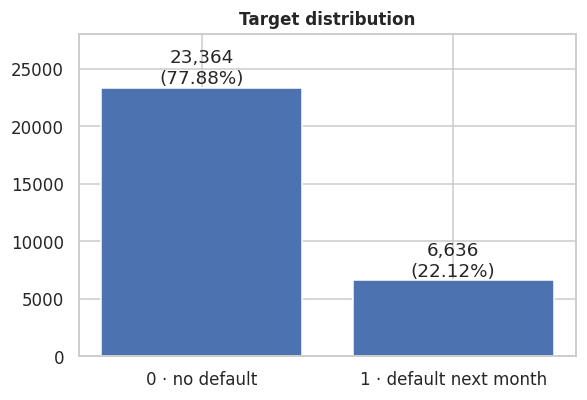

Positive rate: 22.12% (reference document: ~22.12%)  |  imbalance ratio ≈ 3.5 : 1  (moderate)


In [15]:
vc = tw[TW_T].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(5.5, 3.8))
ax.bar(["0 · no default", "1 · default next month"], vc.values)
for i, v in enumerate(vc.values):
    ax.text(i, v, f"{v:,}\n({v / len(tw):.2%})", ha="center", va="bottom")
ax.set_ylim(0, vc.max() * 1.2); ax.set_title("Target distribution")
plt.show()
print(f"Positive rate: {TW_BASE:.2%} (reference document: ~22.12%)  |  imbalance ratio ≈ {(1 - TW_BASE) / TW_BASE:.1f} : 1  (moderate)")

The positive class is ≈ 22 %: a **moderate imbalance**. Use stratified splits/CV and imbalance-aware metrics.

### 2.2 Category codes and data-integrity rules

In [16]:
edu_map  = {0: "0 · undocumented", 1: "1 · graduate school", 2: "2 · university", 3: "3 · high school", 4: "4 · other", 5: "5 · undocumented", 6: "6 · undocumented"}
mar_map  = {0: "0 · undocumented", 1: "1 · married", 2: "2 · single", 3: "3 · other"}
sex_map  = {1: "1 · male", 2: "2 · female"}

print("Category codes actually present:")
for c, m in [("SEX", sex_map), ("EDUCATION", edu_map), ("MARRIAGE", mar_map)]:
    vc = tw[c].value_counts().sort_index()
    display(pd.DataFrame({"code meaning": [m.get(i, "UNKNOWN CODE") for i in vc.index], "rows": vc.values,
                          "% of data": vc.values / len(tw) * 100,
                          "default rate": tw.groupby(c)[TW_T].mean().reindex(vc.index).values}, index=vc.index).rename_axis(c))

Category codes actually present:


,code meaning,rows,% of data,default rate
SEX,,,,
1,1 · male,11888,39.6267,0.2417
2,2 · female,18112,60.3733,0.2078


,code meaning,rows,% of data,default rate
EDUCATION,,,,
0,0 · undocumented,14,0.0467,0.0000
1,1 · graduate school,10585,35.2833,0.1923
2,2 · university,14030,46.7667,0.2373
3,3 · high school,4917,16.3900,0.2516
4,4 · other,123,0.4100,0.0569
5,5 · undocumented,280,0.9333,0.0643
6,6 · undocumented,51,0.1700,0.1569


,code meaning,rows,% of data,default rate
MARRIAGE,,,,
0,0 · undocumented,54,0.1800,0.0926
1,1 · married,13659,45.5300,0.2347
2,2 · single,15964,53.2133,0.2093
3,3 · other,323,1.0767,0.2601


In [17]:
print("Payment-status codes per month (rows = code, columns = month; -2 no consumption, -1 paid duly, 0 revolving, k>=1 delayed k months):")
pay_counts = pd.DataFrame({f"{c} ({MLBL[int(c[-1])]})": tw[c].value_counts() for c in TW_PAY}).fillna(0).astype(int).sort_index()
display(pay_counts)

Payment-status codes per month (rows = code, columns = month; -2 no consumption, -1 paid duly, 0 revolving, k>=1 delayed k months):


,PAY_1 (t),PAY_2 (t-1),PAY_3 (t-2),PAY_4 (t-3),PAY_5 (t-4),PAY_6 (t-5)
-2,2759,3782,4085,4348,4546,4895
-1,5686,6050,5938,5687,5539,5740
0,14737,15730,15764,16455,16947,16286
1,3688,28,4,2,0,0
2,2667,3927,3819,3159,2626,2766
3,322,326,240,180,178,184
4,76,99,76,69,84,49
5,26,25,21,35,17,13
6,11,12,23,5,4,19
7,9,20,27,58,58,46


In [18]:
rules_tw = {
    "EDUCATION ∈ {0,5,6} (undocumented code)": ~tw["EDUCATION"].isin([1, 2, 3, 4]),
    "MARRIAGE == 0 (undocumented code)": ~tw["MARRIAGE"].isin([1, 2, 3]),
    "Any PAY_k == -2 ('no consumption')": (tw[TW_PAY] == -2).any(axis=1),
    "Any PAY_k == 0 (revolving; not in the original codebook)": (tw[TW_PAY] == 0).any(axis=1),
    "Any PAY_k >= 1 (delayed payment)": (tw[TW_PAY] >= 1).any(axis=1),
    "Any PAY_k >= 4 (long delay)": (tw[TW_PAY] >= 4).any(axis=1),
    "Any BILL_AMT < 0 (credit balance / refund)": (tw[TW_BILL] < 0).any(axis=1),
    "Any BILL_AMT > LIMIT_BAL (over limit)": tw[TW_BILL].gt(tw["LIMIT_BAL"], axis=0).any(axis=1),
    "All six BILL_AMT == 0 (dormant card)": (tw[TW_BILL] == 0).all(axis=1),
    "All six PAY_AMT == 0 (never paid anything)": (tw[TW_PAMT] == 0).all(axis=1),
    "PAY_1 == -1 (paid duly) but PAY_AMT1 == 0 while BILL_AMT2 > 0": (tw["PAY_1"] == -1) & (tw["PAY_AMT1"] == 0) & (tw["BILL_AMT2"] > 0),
    "AGE < 21": tw["AGE"] < 21,
    "AGE > 70": tw["AGE"] > 70,
}
display(rules_table(tw, TW_T, rules_tw))

,rows,% of data,positive rate (flagged rows),lift vs overall
rule,,,,
"EDUCATION ∈ {0,5,6} (undocumented code)",345,1.1500,0.0754,0.3407
MARRIAGE == 0 (undocumented code),54,0.1800,0.0926,0.4186
Any PAY_k == -2 ('no consumption'),6561,21.8700,0.1907,0.8620
Any PAY_k == 0 (revolving; not in the original codebook),21173,70.5767,0.2006,0.9068
Any PAY_k >= 1 (delayed payment),10069,33.5633,0.4273,1.9315
Any PAY_k >= 4 (long delay),404,1.3467,0.6411,2.8982
Any BILL_AMT < 0 (credit balance / refund),1930,6.4333,0.1648,0.7449
Any BILL_AMT > LIMIT_BAL (over limit),3931,13.1033,0.3009,1.3605
All six BILL_AMT == 0 (dormant card),866,2.8867,0.3661,1.6548


In [19]:
display(quantile_profile(tw, ["LIMIT_BAL", "AGE"] + TW_BILL + TW_PAMT))

,min,p1,p5,p25,median,p75,p95,p99,p99.9,max,mean,std,skew,kurtosis,missing %
LIMIT_BAL,"10,000.0000","10,000.0000","20,000.0000","50,000.0000","140,000.0000","240,000.0000","430,000.0000","500,000.0000","700,000.0000","1,000,000.0000","167,484.3227","129,747.6616",0.9929,0.5363,0.0000
AGE,21.0000,22.0000,23.0000,28.0000,34.0000,41.0000,53.0000,60.0000,69.0000,79.0000,35.4855,9.2179,0.7322,0.0443,0.0000
BILL_AMT1,"-165,580.0000",-81.0000,0.0000,"3,558.7500","22,381.5000","67,091.0000","201,203.0500","350,110.6800","519,901.5520","964,511.0000","51,223.3309","73,635.8606",2.6639,9.8063,0.0000
BILL_AMT2,"-69,777.0000",-200.0000,0.0000,"2,984.7500","21,200.0000","64,006.2500","194,792.2000","337,495.2800","509,230.2410","983,931.0000","49,179.0752","71,173.7688",2.7052,10.3029,0.0000
BILL_AMT3,"-157,264.0000",-200.0000,0.0000,"2,666.2500","20,088.5000","60,164.7500","187,821.0500","325,030.3900","491,956.7620","1,664,089.0000","47,013.1548","69,349.3874",3.0878,19.7833,0.0000
BILL_AMT4,"-170,000.0000",-212.0200,0.0000,"2,326.7500","19,052.0000","54,506.0000","174,333.3500","304,997.2700","479,800.1780","891,586.0000","43,262.9490","64,332.8561",2.8220,11.3093,0.0000
BILL_AMT5,"-81,334.0000",-232.0100,0.0000,"1,763.0000","18,104.5000","50,190.5000","165,794.3000","285,868.3300","454,852.7950","927,171.0000","40,311.4010","60,797.1558",2.8764,12.3059,0.0000
BILL_AMT6,"-339,603.0000",-331.0300,0.0000,"1,256.0000","17,071.0000","49,198.2500","161,912.0000","279,505.0600","447,544.4830","961,664.0000","38,871.7604","59,554.1075",2.8466,12.2707,0.0000
PAY_AMT1,0.0000,0.0000,0.0000,"1,000.0000","2,100.0000","5,006.0000","18,428.2000","66,522.1800","231,788.7690","873,552.0000","5,663.5805","16,563.2804",14.6684,415.2547,0.0000
PAY_AMT2,0.0000,0.0000,0.0000,833.0000,"2,009.0000","5,000.0000","19,004.3500","76,651.0200","263,113.1130","1,684,259.0000","5,921.1635","23,040.8704",30.4538,"1,641.6319",0.0000


**ML implication.**
| Finding | Decision |
|---|---|
| `EDUCATION` ∈ {0, 5, 6} and `MARRIAGE` = 0 are undocumented | Merge into the documented "other" bucket **or** keep a separate "unknown" level — decide from the default rates shown above (do not drop rows). *This pipeline merges them into `"other"` in section 3.* |
| `SEX`, `EDUCATION`, `MARRIAGE` are nominal codes | One-hot / target-safe encoding; **never** treat as ordered numbers (except a defensible ordinal `EDUCATION`) |
| `PAY_k` mixes three meanings (−2, −1, 0 = no delay; ≥ 1 = delay) | Keep the raw code for trees; create `delay = max(PAY,0)` and separate flags (`revolving`, `no_consumption`) for linear models |
| Negative bills / bills above limit | Genuine credit balances or over-limit usage — **keep** (they are informative), cap extremes |
| Amounts are heavily right-skewed with a spike at 0 | `log1p` / signed-log, plus "zero" flags |

### 2.3 Demographics

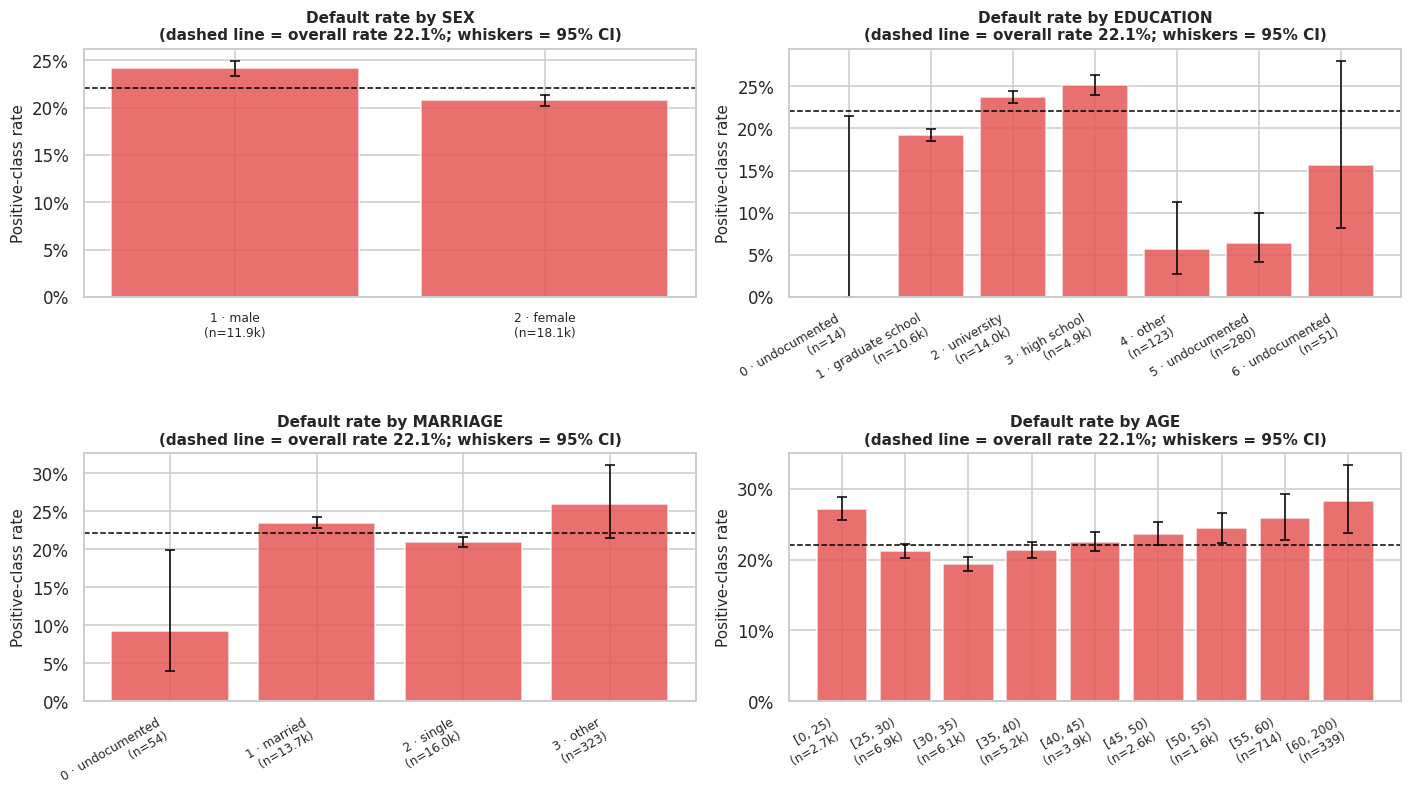

,chi²,p-value,Cramér's V (effect size)
variable,,,
SEX,47.7088,0.0000,0.0399
EDUCATION,163.2166,0.0000,0.0738
MARRIAGE,35.6624,0.0000,0.0345
age_bin,95.5185,0.0000,0.0564


In [20]:
tw["age_bin"] = pd.cut(tw["AGE"], [0, 25, 30, 35, 40, 45, 50, 55, 60, 200], right=False)
fig, axes = plt.subplots(2, 2, figsize=(13, 7.5))
tw_demo_rates = {
    "SEX": rate_table(tw, "SEX", TW_T, label_map=sex_map),
    "EDUCATION": rate_table(tw, "EDUCATION", TW_T, label_map=edu_map),
    "MARRIAGE": rate_table(tw, "MARRIAGE", TW_T, label_map=mar_map),
    "AGE": rate_table(tw, "age_bin", TW_T),
}
for ax, (name, t) in zip(axes.ravel(), tw_demo_rates.items()):
    plot_rate(t, ax, f"Default rate by {name}", base=TW_BASE, rotate=30 if name != "SEX" else 0)
plt.show()

rows = []
for c in ["SEX", "EDUCATION", "MARRIAGE", "age_bin"]:
    chi2, p, v = cramers_v(tw[c], tw[TW_T])
    rows.append({"variable": c, "chi²": chi2, "p-value": p, "Cramér's V (effect size)": v})
display(pd.DataFrame(rows).set_index("variable"))

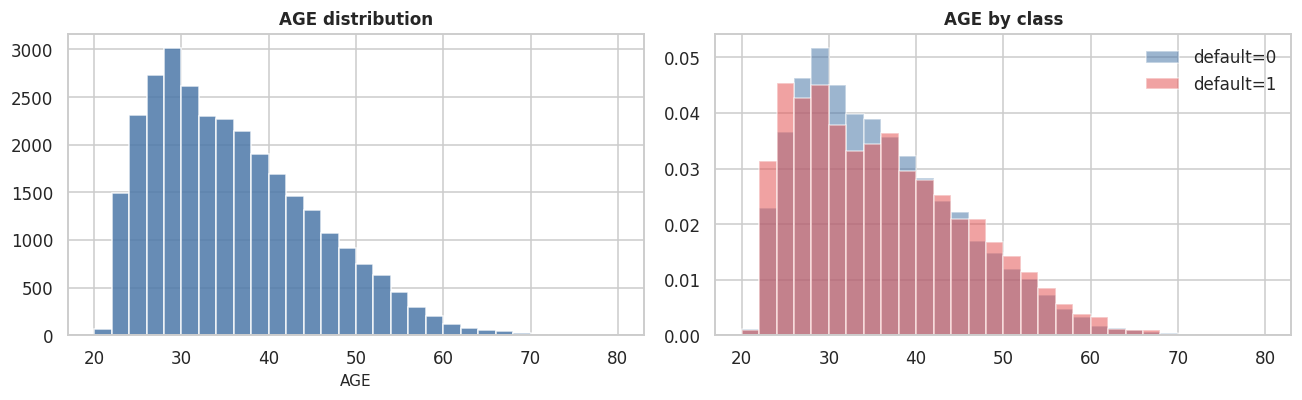

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].hist(tw["AGE"], bins=range(20, 82, 2), color=C0, alpha=.85); axes[0].set_title("AGE distribution"); axes[0].set_xlabel("AGE")
for k, col in CLASS_COLORS.items():
    axes[1].hist(tw.loc[tw[TW_T] == k, "AGE"], bins=range(20, 82, 2), density=True, alpha=.55, color=col, label=f"default={k}")
axes[1].set_title("AGE by class"); axes[1].legend(frameon=False)
plt.show()

### 2.4 Credit limit (`LIMIT_BAL`)

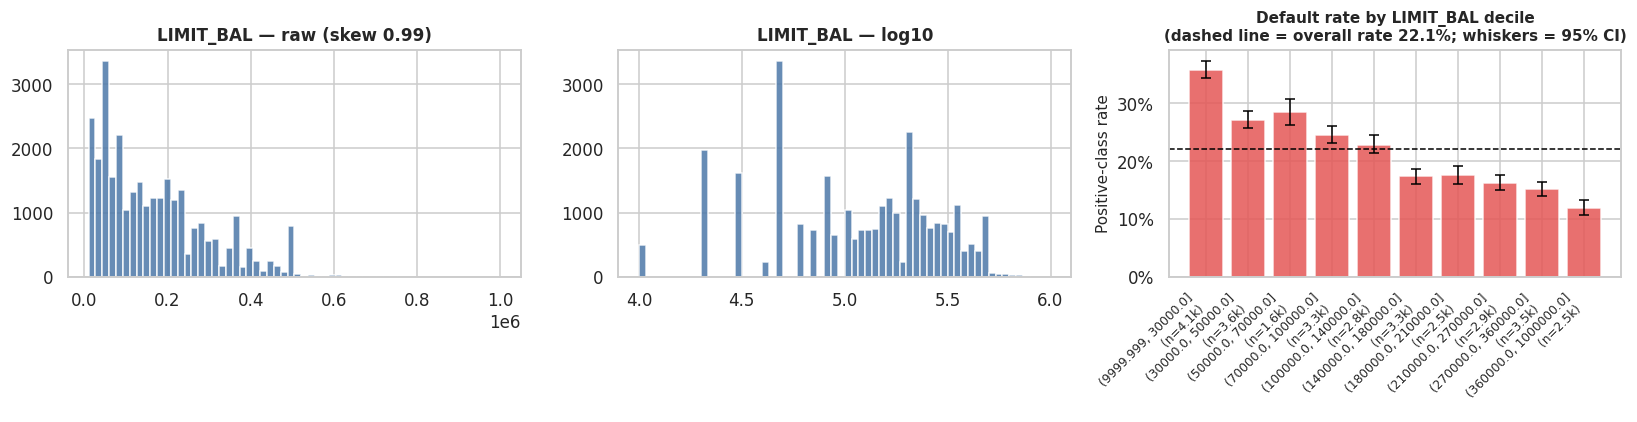

,mean,25%,50%,75%
default,,,,
0,"178,099.7261","70,000.0000","150,000.0000","250,000.0000"
1,"130,109.6564","50,000.0000","90,000.0000","200,000.0000"


Mann-Whitney p = 1.23e-189   |   AUC of LIMIT_BAL alone = 0.618


In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(tw["LIMIT_BAL"], bins=60, color=C0, alpha=.85); axes[0].set_title(f"LIMIT_BAL — raw (skew {tw['LIMIT_BAL'].skew():.2f})")
axes[1].hist(np.log10(tw["LIMIT_BAL"].clip(lower=1)), bins=60, color=C0, alpha=.85); axes[1].set_title("LIMIT_BAL — log10")
plot_rate(rate_table(tw, "LIMIT_BAL", TW_T, q=10), axes[2], "Default rate by LIMIT_BAL decile", base=TW_BASE, rotate=45)
plt.show()

lim = tw.groupby(TW_T)["LIMIT_BAL"].describe()[["mean", "25%", "50%", "75%"]]
display(lim)
u = stats.mannwhitneyu(tw.loc[tw[TW_T] == 0, "LIMIT_BAL"], tw.loc[tw[TW_T] == 1, "LIMIT_BAL"])
print(f"Mann-Whitney p = {u.pvalue:.2e}   |   AUC of LIMIT_BAL alone = {max(roc_auc_score(tw[TW_T], tw['LIMIT_BAL']), 1 - roc_auc_score(tw[TW_T], tw['LIMIT_BAL'])):.3f}")

### 2.5 Payment status: how late, and for how many months?

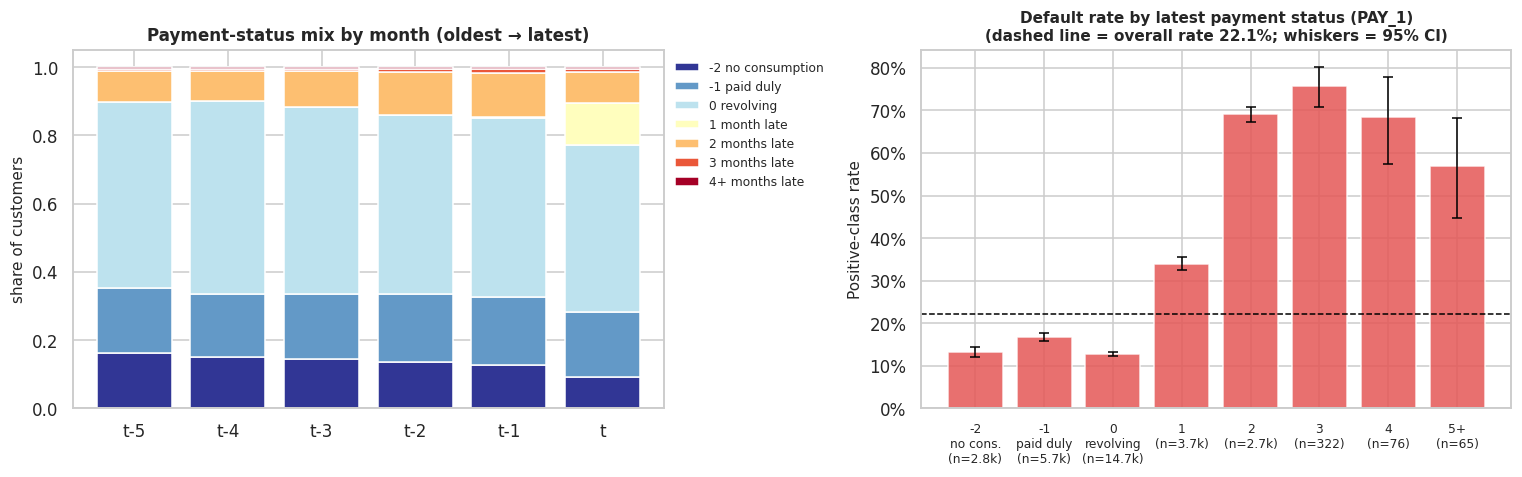

,n,positives,rate,ci_lo,ci_hi,lift
-2\nno cons.,2759,365,0.1323,0.1202,0.1454,0.5981
-1\npaid duly,5686,954,0.1678,0.1583,0.1777,0.7585
0\nrevolving,14737,1888,0.1281,0.1228,0.1336,0.5792
1,3688,1252,0.3395,0.3244,0.3549,1.5347
2,2667,1844,0.6914,0.6736,0.7087,3.1257
3,322,244,0.7578,0.7081,0.8013,3.4257
4,76,52,0.6842,0.5730,0.7777,3.0932
5+,65,37,0.5692,0.4483,0.6824,2.5734


In [23]:
order = [6, 5, 4, 3, 2, 1]                                   # oldest -> latest for time-ordered plots
cats = [-2, -1, 0, 1, 2, 3, 4]
dist = pd.DataFrame({MLBL[k]: tw[f"PAY_{k}"].clip(-2, 4).value_counts(normalize=True).reindex(cats).fillna(0) for k in order})
dist.index = ["-2 no consumption", "-1 paid duly", "0 revolving", "1 month late", "2 months late", "3 months late", "4+ months late"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
dist.T.plot(kind="bar", stacked=True, ax=axes[0], colormap="RdYlBu_r", width=.8)
axes[0].set_title("Payment-status mix by month (oldest → latest)"); axes[0].set_ylabel("share of customers")
axes[0].legend(bbox_to_anchor=(1.0, 1), frameon=False, fontsize=8); axes[0].tick_params(axis="x", rotation=0)

t = rate_table(tw, "PAY_1", TW_T, cap=5)
t.index = [{"-2": "-2\nno cons.", "-1": "-1\npaid duly", "0": "0\nrevolving"}.get(i, i) for i in t.index]
plot_rate(t, axes[1], "Default rate by latest payment status (PAY_1)", base=TW_BASE)
plt.show()
display(t)

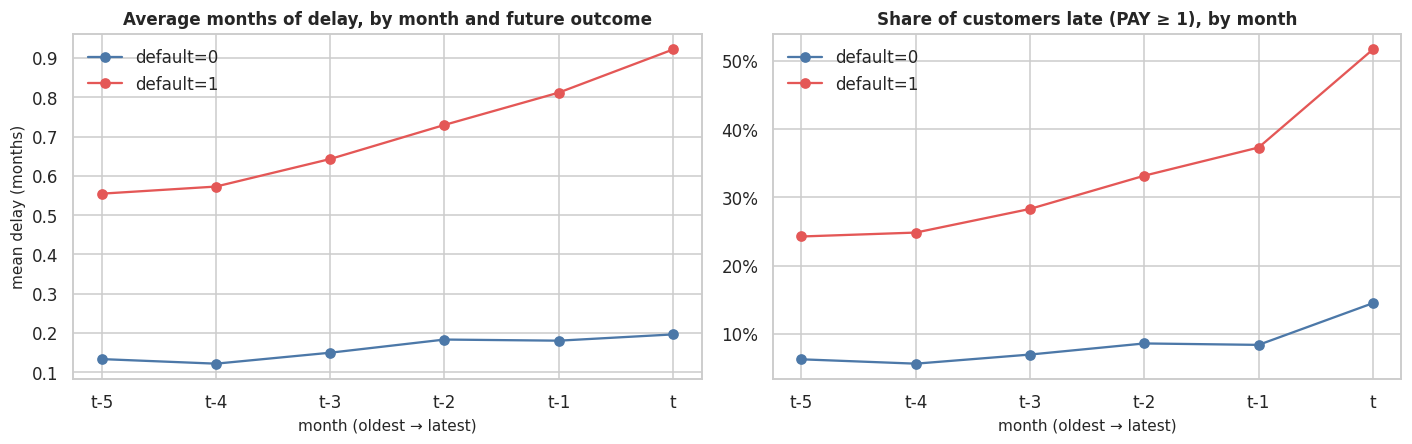

In [24]:
delay = {k: tw[f"PAY_{k}"].clip(lower=0) for k in order}
late  = {k: (tw[f"PAY_{k}"] >= 1).astype(int) for k in order}
traj_delay = pd.DataFrame({MLBL[k]: delay[k].groupby(tw[TW_T]).mean() for k in order})
traj_late  = pd.DataFrame({MLBL[k]: late[k].groupby(tw[TW_T]).mean() for k in order})

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for cls, col in CLASS_COLORS.items():
    axes[0].plot(traj_delay.columns, traj_delay.loc[cls], marker="o", color=col, label=f"default={cls}")
    axes[1].plot(traj_late.columns, traj_late.loc[cls], marker="o", color=col, label=f"default={cls}")
axes[0].set_title("Average months of delay, by month and future outcome"); axes[0].set_ylabel("mean delay (months)")
axes[1].set_title("Share of customers late (PAY ≥ 1), by month"); axes[1].yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
for ax in axes: ax.legend(frameon=False); ax.set_xlabel("month (oldest → latest)")
plt.show()

**Persistence:** how likely is a customer to stay late from one month to the next?

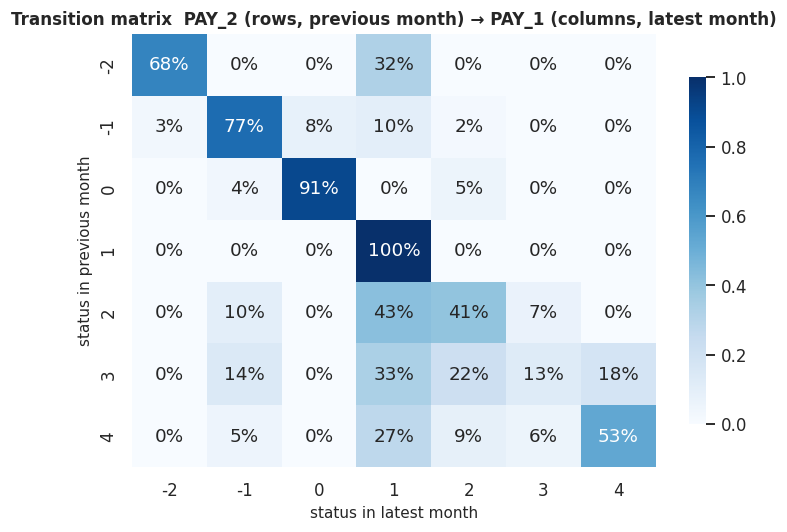

P(late this month | late last month)  = 89.9%
P(late this month | not late last month) = 11.1%


In [25]:
tr = pd.crosstab(tw["PAY_2"].clip(-2, 4), tw["PAY_1"].clip(-2, 4), normalize="index")
fig, ax = plt.subplots(figsize=(6.8, 5))
sns.heatmap(tr, annot=True, fmt=".0%", cmap="Blues", ax=ax, cbar_kws={"shrink": .8})
ax.set_title("Transition matrix  PAY_2 (rows, previous month) → PAY_1 (columns, latest month)")
ax.set_xlabel("status in latest month"); ax.set_ylabel("status in previous month")
plt.show()

stay = ((tw["PAY_2"] >= 1) & (tw["PAY_1"] >= 1)).sum() / (tw["PAY_2"] >= 1).sum()
enter = ((tw["PAY_2"] <= 0) & (tw["PAY_1"] >= 1)).sum() / (tw["PAY_2"] <= 0).sum()
print(f"P(late this month | late last month)  = {stay:.1%}\nP(late this month | not late last month) = {enter:.1%}")

### 2.6 Bill amounts

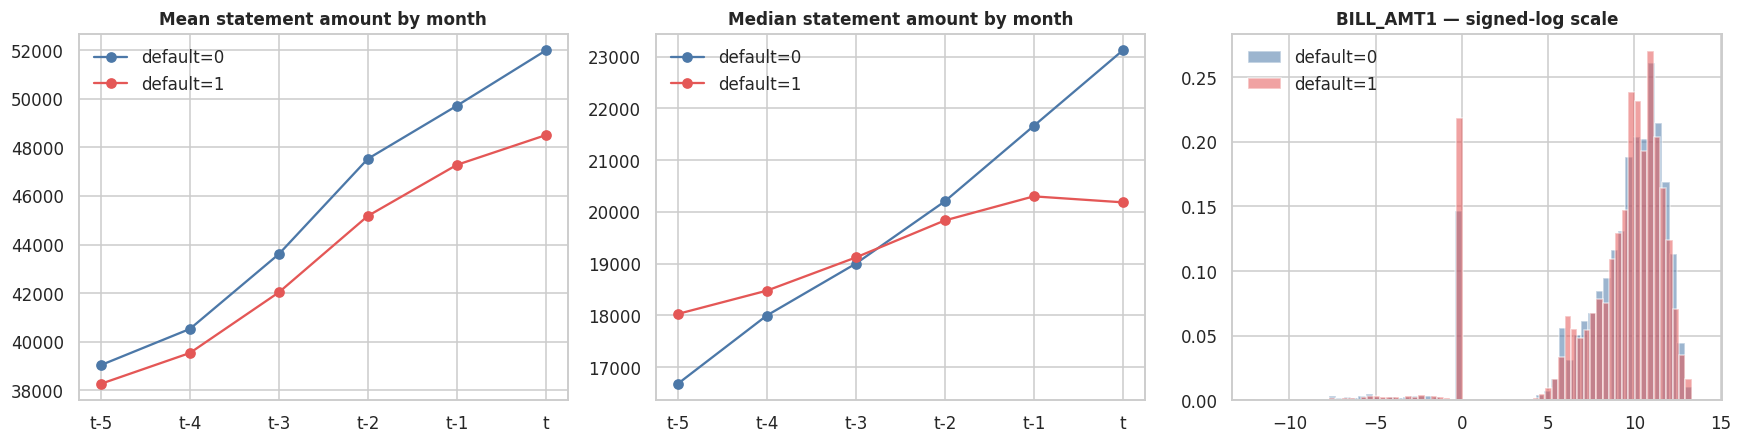

In [26]:
slog = lambda x: np.sign(x) * np.log1p(np.abs(x))
mean_b   = pd.DataFrame({MLBL[k]: tw[f"BILL_AMT{k}"].groupby(tw[TW_T]).mean() for k in order})
median_b = pd.DataFrame({MLBL[k]: tw[f"BILL_AMT{k}"].groupby(tw[TW_T]).median() for k in order})

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
for cls, col in CLASS_COLORS.items():
    axes[0].plot(mean_b.columns, mean_b.loc[cls], marker="o", color=col, label=f"default={cls}")
    axes[1].plot(median_b.columns, median_b.loc[cls], marker="o", color=col, label=f"default={cls}")
axes[0].set_title("Mean statement amount by month"); axes[1].set_title("Median statement amount by month")
for ax in axes[:2]: ax.legend(frameon=False)
for cls, col in CLASS_COLORS.items():
    axes[2].hist(slog(tw.loc[tw[TW_T] == cls, "BILL_AMT1"]), bins=60, density=True, alpha=.55, color=col, label=f"default={cls}")
axes[2].set_title("BILL_AMT1 — signed-log scale"); axes[2].legend(frameon=False)
plt.show()

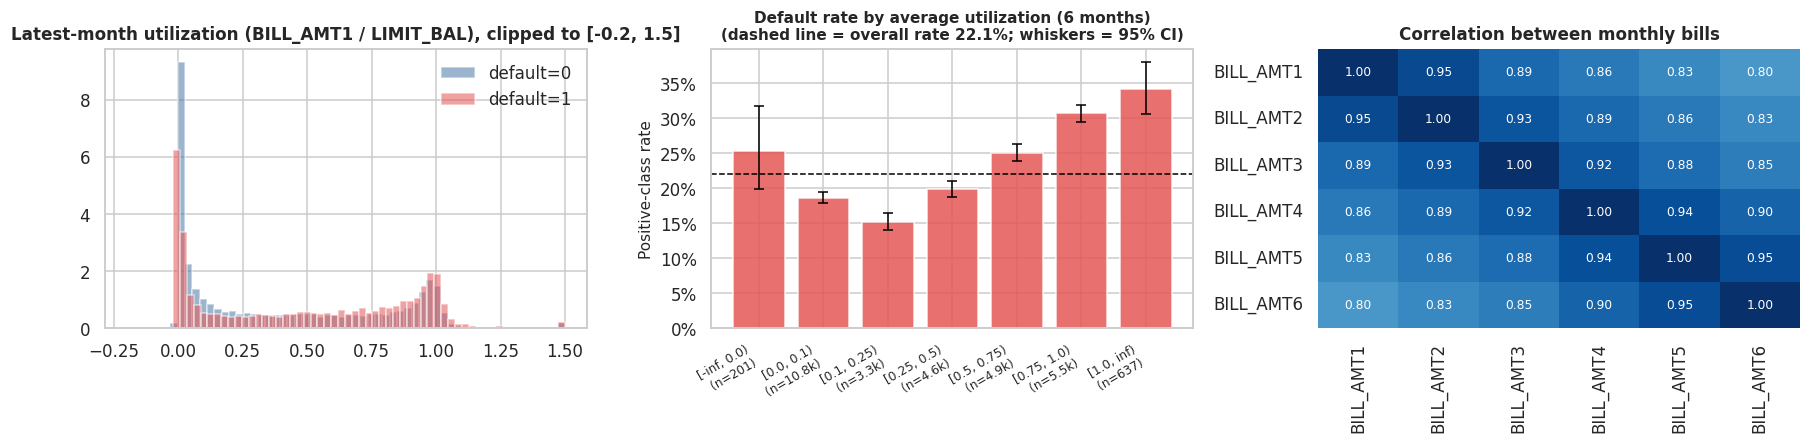

Mean off-diagonal correlation between the six BILL_AMT columns: 0.89


In [27]:
tw["util_now"] = tw["BILL_AMT1"] / tw["LIMIT_BAL"]
tw["util_avg"] = tw[TW_BILL].mean(axis=1) / tw["LIMIT_BAL"]
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
for cls, col in CLASS_COLORS.items():
    axes[0].hist(tw.loc[tw[TW_T] == cls, "util_now"].clip(-.2, 1.5), bins=60, density=True, alpha=.55, color=col, label=f"default={cls}")
axes[0].set_title("Latest-month utilization (BILL_AMT1 / LIMIT_BAL), clipped to [-0.2, 1.5]"); axes[0].legend(frameon=False)
plot_rate(rate_table(tw, "util_avg", TW_T, bins=[-np.inf, 0, .1, .25, .5, .75, 1, np.inf]), axes[1], "Default rate by average utilization (6 months)", base=TW_BASE, rotate=30)
bc = tw[TW_BILL].corr()
sns.heatmap(bc, annot=True, fmt=".2f", cmap="Blues", vmin=.5, vmax=1, ax=axes[2], cbar=False, annot_kws={"size": 8})
axes[2].set_title("Correlation between monthly bills")
plt.show()
print(f"Mean off-diagonal correlation between the six BILL_AMT columns: {bc.values[~np.eye(6, dtype=bool)].mean():.2f}")

**Reading the output.** Statement amounts on their own are weak predictors (defaulters do not have systematically bigger bills), but **relative to the limit** they become informative. The six bills are extremely correlated with each other (a customer's balance persists month to month) → severe multicollinearity if all six are used raw. **ML implication:** replace the six raw bills with `avg_bill`, `bill_trend`, `bill_volatility`, and utilization ratios; cap negative / extreme values.

### 2.7 Payment amounts and payment behaviour relative to the bill

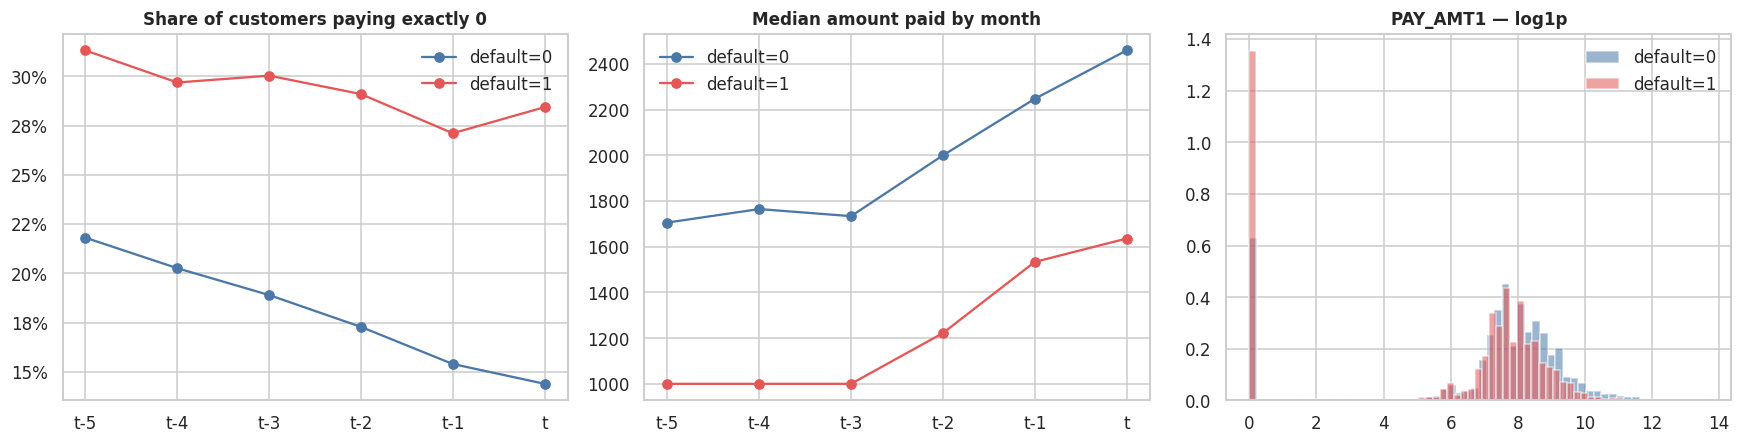

In [28]:
zero_share = pd.DataFrame({MLBL[k]: (tw[f"PAY_AMT{k}"] == 0).groupby(tw[TW_T]).mean() for k in order})
med_pay    = pd.DataFrame({MLBL[k]: tw[f"PAY_AMT{k}"].groupby(tw[TW_T]).median() for k in order})
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
for cls, col in CLASS_COLORS.items():
    axes[0].plot(zero_share.columns, zero_share.loc[cls], marker="o", color=col, label=f"default={cls}")
    axes[1].plot(med_pay.columns, med_pay.loc[cls], marker="o", color=col, label=f"default={cls}")
    axes[2].hist(np.log1p(tw.loc[tw[TW_T] == cls, "PAY_AMT1"]), bins=60, density=True, alpha=.55, color=col, label=f"default={cls}")
axes[0].set_title("Share of customers paying exactly 0"); axes[0].yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
axes[1].set_title("Median amount paid by month"); axes[2].set_title("PAY_AMT1 — log1p")
for ax in axes: ax.legend(frameon=False)
plt.show()

**Payment-to-bill ratio:** amount paid in month k / statement of the previous month (`BILL_AMT(k+1)`), clipped to [0, 1].

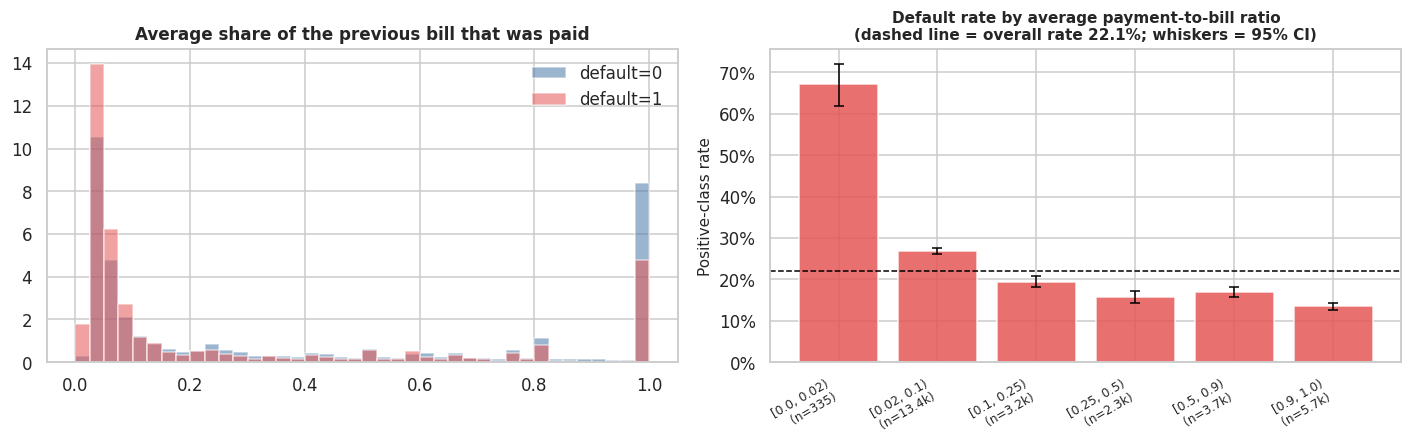

Customers with no valid ratio (never had a positive bill): 4.7%


In [29]:
ratio = {}
for k in range(1, 6):
    b = tw[f"BILL_AMT{k + 1}"]
    ratio[k] = (tw[f"PAY_AMT{k}"] / b.where(b > 0)).clip(0, 1)
R = pd.DataFrame(ratio)
tw["pay_ratio_avg"] = R.mean(axis=1)
tw["pay_ratio_latest"] = R[1]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for cls, col in CLASS_COLORS.items():
    axes[0].hist(tw.loc[tw[TW_T] == cls, "pay_ratio_avg"].dropna(), bins=40, density=True, alpha=.55, color=col, label=f"default={cls}")
axes[0].set_title("Average share of the previous bill that was paid"); axes[0].legend(frameon=False)
plot_rate(rate_table(tw, "pay_ratio_avg", TW_T, bins=[0, .02, .1, .25, .5, .9, 1.0001]), axes[1], "Default rate by average payment-to-bill ratio", base=TW_BASE, rotate=30)
plt.show()
print(f"Customers with no valid ratio (never had a positive bill): {tw['pay_ratio_avg'].isna().mean():.1%}")

**Reading the output.** Paying a **small fraction of the bill** (minimum-payment behaviour) is expected to be much riskier than paying in full, even when the absolute amount looks large. **ML implication:** ratios (`pay_ratio_*`) carry information that raw `PAY_AMT*` and `BILL_AMT*` hide — engineer them; guard against division by zero when the bill is ≤ 0.

### 2.8 Candidate engineered features: do they beat the raw columns?
The features are built by `client_level_features(...)` (defined in the setup section). **Section 3 reuses the exact same function**, so the features tested here are the ones that end up in the final table.

In [30]:
fe = client_level_features(tw, TW_PAY)
tw_fe = pd.concat([tw, fe], axis=1)
print("Engineered features:", fe.shape[1])
display(fe.describe().T[["mean", "std", "min", "50%", "max"]])

Engineered features: 26


,mean,std,min,50%,max
n_late_months,0.8342,1.5543,0.0000,0.0000,6.0000
max_delay,0.6822,1.0735,0.0000,0.0000,8.0000
mean_delay,0.2813,0.6016,0.0000,0.0000,6.0000
delay_trend,0.0283,0.1702,-1.5429,0.0000,1.1429
recent_vs_hist_delay,0.0913,0.5744,-5.3333,0.0000,3.3333
consecutive_late_to_now,0.6184,1.4676,0.0000,0.0000,6.0000
n_revolving_months,3.1973,2.5146,0.0000,4.0000,6.0000
n_no_consumption_months,0.8138,1.7936,0.0000,0.0000,6.0000
avg_bill,"44,976.9452","63,260.7219","-56,043.1667","21,051.8333","877,313.8333"
max_bill,"60,572.4369","78,404.8140","-6,029.0000","31,208.5000","1,664,089.0000"


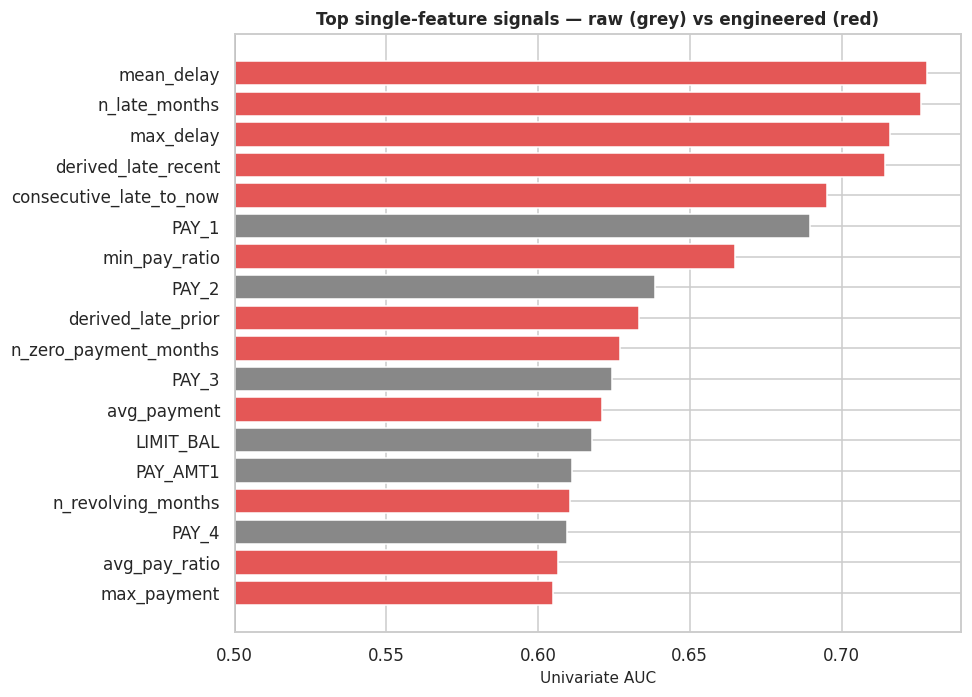

,AUC (direction-free),direction,Cliff's delta,mutual info,median | y=0,median | y=1,Mann-Whitney p,type
feature,,,,,,,,
mean_delay,0.7281,higher = riskier,0.4562,0.0751,0.0000,0.3333,0.0000,engineered
n_late_months,0.7261,higher = riskier,0.4522,0.0766,0.0000,1.0000,0.0000,engineered
max_delay,0.7158,higher = riskier,0.4316,0.0686,0.0000,2.0000,0.0000,engineered
derived_late_recent,0.7145,higher = riskier,0.4289,0.0711,0.0000,1.0000,0.0000,engineered
consecutive_late_to_now,0.6953,higher = riskier,0.3906,0.0671,0.0000,1.0000,0.0000,engineered
PAY_1,0.6897,higher = riskier,0.3794,0.0740,0.0000,1.0000,0.0000,raw
min_pay_ratio,0.6650,higher = safer,-0.3300,0.0431,0.0363,0.0151,0.0000,engineered
PAY_2,0.6386,higher = riskier,0.2771,0.0498,0.0000,0.0000,0.0000,raw
derived_late_prior,0.6333,higher = riskier,0.2667,0.0388,0.0000,0.0000,0.0000,engineered


In [31]:
raw_feats = ["LIMIT_BAL", "AGE"] + TW_PAY + TW_BILL + TW_PAMT
sig_raw = signal_table(tw_fe, raw_feats, TW_T);           sig_raw["type"] = "raw"
sig_eng = signal_table(tw_fe, list(fe.columns), TW_T);    sig_eng["type"] = "engineered"
tw_signal = pd.concat([sig_raw, sig_eng]).sort_values("AUC (direction-free)", ascending=False)

top = tw_signal.head(18).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 6.5))
ax.barh(top.index, top["AUC (direction-free)"] - .5, left=.5, color=[C1 if t == "engineered" else "#888888" for t in top["type"]])
ax.axvline(.5, color="black", lw=1)
ax.set_xlabel("Univariate AUC"); ax.set_title("Top single-feature signals — raw (grey) vs engineered (red)")
plt.show()
display(tw_signal.head(15).style.format(precision=4).background_gradient(subset=["AUC (direction-free)"], cmap="Reds"))

#### Trajectory archetypes — improving, stable or deteriorating?
Turning the payment-status *path* into a simple label operationalises the "risk is improving / stable / deteriorating" idea of monthly monitoring.

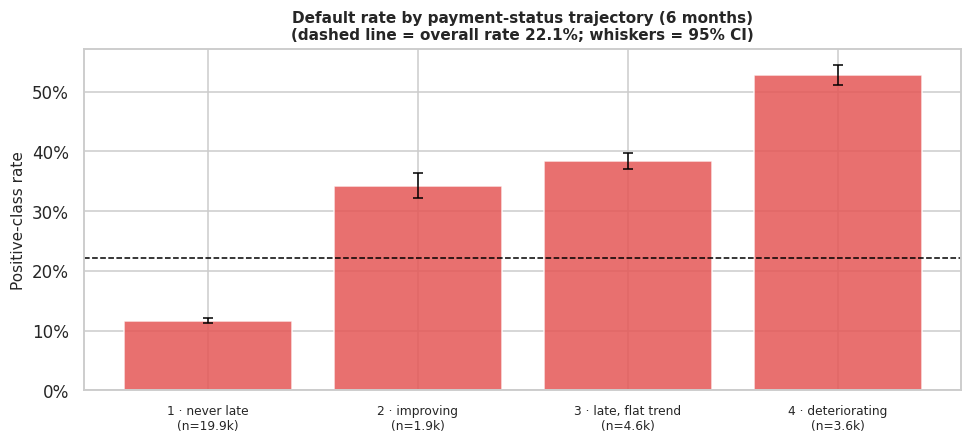

,n,positives,rate,ci_lo,ci_hi,lift
g,,,,,,
1 · never late,19931,2334,0.1171,0.1127,0.1216,0.5294
2 · improving,1894,649,0.3427,0.3216,0.3643,1.5491
"3 · late, flat trend",4605,1769,0.3841,0.3702,0.3983,1.7367
4 · deteriorating,3570,1884,0.5277,0.5113,0.5441,2.3858


In [32]:
tw_fe["trajectory"] = trajectory_label(tw_fe)
tr_rate = rate_table(tw_fe, "trajectory", TW_T)
fig, ax = plt.subplots(figsize=(9, 4.2))
plot_rate(tr_rate, ax, "Default rate by payment-status trajectory (6 months)", base=TW_BASE)
plt.show()
display(tr_rate)

**ML implication.** If engineered sequence features (late-month counts, trend, consecutive lateness, payment ratios) reach or exceed the strongest raw column (`PAY_1`) in the chart above, that is direct evidence for building the monthly-monitoring model on **history-aware features** rather than on the latest snapshot. The trajectory table also gives an interpretable *traffic-light* segmentation (improving / stable / deteriorating) that can be shown to end users.

### 2.9 Correlation and redundancy

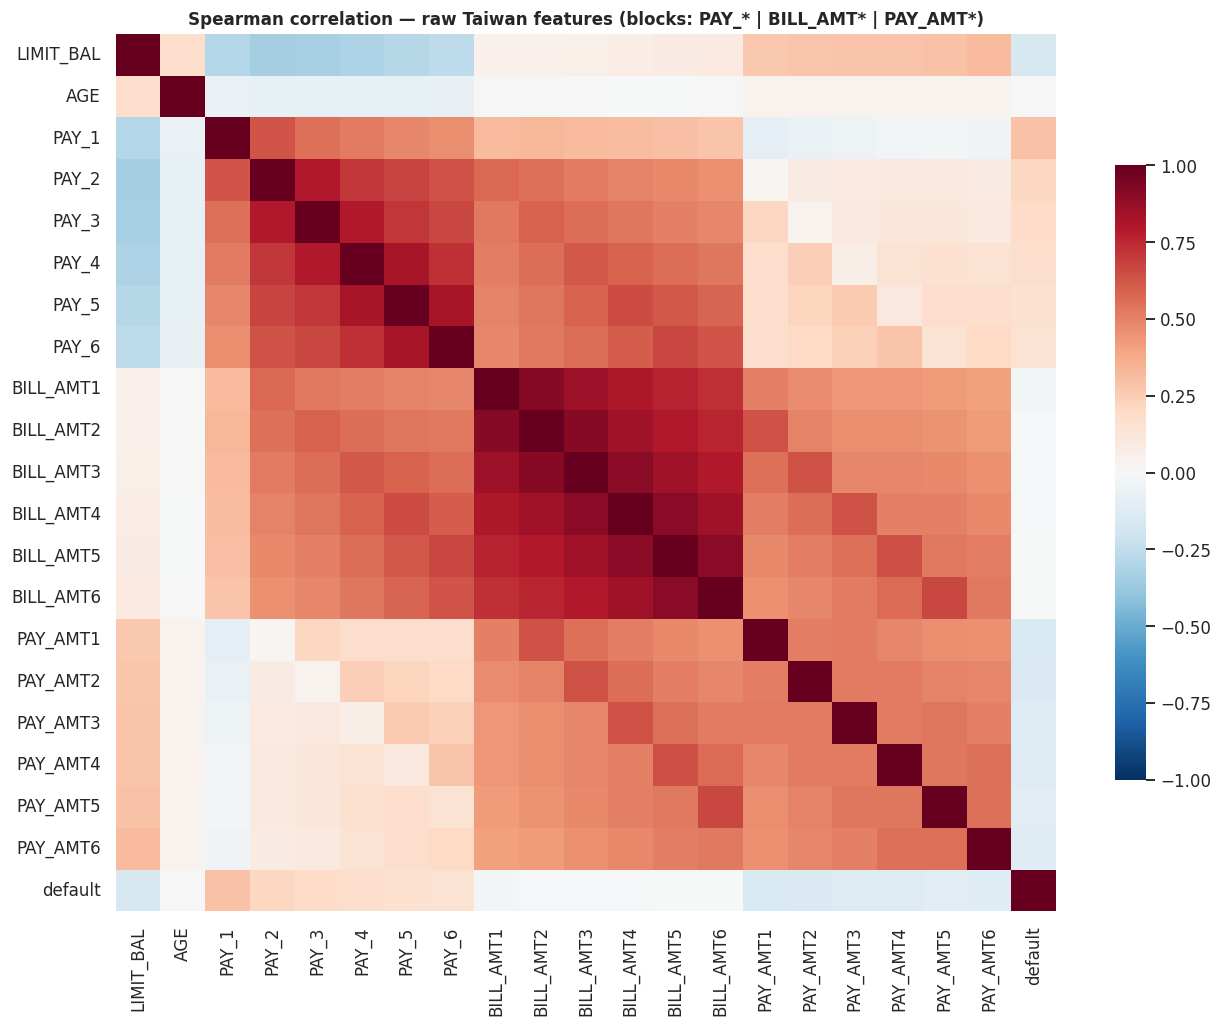

,mean pairwise Spearman inside block
PAY_1..6,0.6686
BILL_AMT1..6,0.8409
PAY_AMT1..6,0.5100


In [33]:
num_cols = ["LIMIT_BAL", "AGE"] + TW_PAY + TW_BILL + TW_PAMT + [TW_T]
cm = tw[num_cols].corr(method="spearman")
fig, ax = plt.subplots(figsize=(12, 9.5))
sns.heatmap(cm, cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax, cbar_kws={"shrink": .7},
            xticklabels=True, yticklabels=True)
ax.set_title("Spearman correlation — raw Taiwan features (blocks: PAY_* | BILL_AMT* | PAY_AMT*)")
plt.show()

def block_mean(cols):
    m = tw[cols].corr(method="spearman").values
    return m[~np.eye(len(cols), dtype=bool)].mean()
display(pd.DataFrame({"mean pairwise Spearman inside block": {"PAY_1..6": block_mean(TW_PAY), "BILL_AMT1..6": block_mean(TW_BILL), "PAY_AMT1..6": block_mean(TW_PAMT)}}))

In [34]:
v_raw = vif_table(tw[TW_BILL + TW_PAMT + ["LIMIT_BAL", "AGE"]].clip(upper=tw[TW_BILL + TW_PAMT + ["LIMIT_BAL", "AGE"]].quantile(.999), axis=1))
eng_small = ["n_late_months", "max_delay", "delay_trend", "avg_utilization", "bill_volatility_over_limit", "avg_pay_ratio", "n_zero_payment_months", "payment_trend_over_limit"]
v_eng = vif_table(tw_fe[["LIMIT_BAL", "AGE"] + eng_small].fillna(tw_fe[["LIMIT_BAL", "AGE"] + eng_small].median()))
print("VIF — raw amount columns (expect BILL_AMT* to dominate):"); display(v_raw.head(8))
print("VIF — compact engineered set:"); display(v_eng)

VIF — raw amount columns (expect BILL_AMT* to dominate):


,VIF
BILL_AMT2,26.9742
BILL_AMT5,26.0736
BILL_AMT3,23.7201
BILL_AMT4,21.9422
BILL_AMT6,15.2631
BILL_AMT1,14.0828
PAY_AMT2,1.9204
PAY_AMT5,1.7186


VIF — compact engineered set:


,VIF
n_late_months,3.2736
max_delay,3.2589
avg_utilization,2.6121
avg_pay_ratio,1.8596
n_zero_payment_months,1.4070
LIMIT_BAL,1.3076
bill_volatility_over_limit,1.2890
delay_trend,1.0427
payment_trend_over_limit,1.0374
AGE,1.0247


**ML implication.** The `BILL_AMT*` block is close to collinear (very high VIF); `PAY_*` columns are also strongly inter-correlated (persistence). For **logistic regression** use the compact engineered set (low VIF) or regularisation (L1/L2); for **tree ensembles** collinearity does not hurt prediction, but it dilutes feature-importance rankings — inspect with permutation importance / SHAP grouped by feature family.

### 2.10 Scorecard

In [35]:
best_raw = tw_signal[tw_signal["type"] == "raw"].iloc[0]
best_eng = tw_signal[tw_signal["type"] == "engineered"].iloc[0]
tw_scorecard = pd.Series({
    "Rows": f"{len(tw):,}",
    "Positive rate": f"{TW_BASE:.2%}",
    "Missing cells": f"{int(tw_raw.isna().sum().sum())}",
    "Undocumented EDUCATION codes (0/5/6)": f"{(~tw['EDUCATION'].isin([1, 2, 3, 4])).mean():.2%}",
    "Undocumented MARRIAGE code (0)": f"{(~tw['MARRIAGE'].isin([1, 2, 3])).mean():.2%}",
    "Customers with any negative bill": f"{(tw[TW_BILL] < 0).any(axis=1).mean():.1%}",
    "Customers late (PAY ≥ 1) in at least one month": f"{(tw[TW_PAY] >= 1).any(axis=1).mean():.1%}",
    "Best raw feature (AUC)": f"{best_raw.name} ({best_raw['AUC (direction-free)']:.3f})",
    "Best engineered feature (AUC)": f"{best_eng.name} ({best_eng['AUC (direction-free)']:.3f})",
    "Mean corr. inside BILL_AMT block": f"{block_mean(TW_BILL):.2f}",
}, name="Taiwan scorecard")
display(tw_scorecard.to_frame())

,Taiwan scorecard
Rows,"30,000"
Positive rate,22.12%
Missing cells,0
Undocumented EDUCATION codes (0/5/6),1.15%
Undocumented MARRIAGE code (0),0.18%
Customers with any negative bill,6.4%
Customers late (PAY ≥ 1) in at least one month,33.6%
Best raw feature (AUC),PAY_1 (0.690)
Best engineered feature (AUC),mean_delay (0.728)
Mean corr. inside BILL_AMT block,0.84


### Taiwan — Finding → Decision (summary)
*Expected patterns based on the documented characteristics of this dataset — confirm each one against the numbers and the scorecard above.*

| # | EDA finding | Modelling decision |
|---|---|---|
| 1 | Positive class ≈ 22 % | Stratified CV · PR-AUC / KS / recall-at-precision · class weights |
| 2 | No missing values, but **undocumented codes** (`EDUCATION` 0/5/6, `MARRIAGE` 0, `PAY` 0/−2) | Map to "other/unknown" (decide from default rates), keep as a category — do not drop |
| 3 | `PAY_*` = status, `PAY_AMT*` = amount (different semantics) | Never mix; treat −2/−1/0 vs ≥ 1 explicitly |
| 4 | `PAY_1` and recent lateness dominate the signal; delay curves diverge before default | Monitoring model on recent + trend features |
| 5 | Late customers stay late (strong persistence) | Sequence features: `n_late_months`, `max_delay`, `consecutive_late_to_now`, `delay_trend` |
| 6 | `BILL_AMT1–6` almost collinear; amounts heavily skewed | Replace by average / trend / volatility / utilization; `log1p`, cap |
| 7 | Payment *ratio* (paid ÷ previous bill) is informative beyond raw amounts | Engineer `avg_pay_ratio`, `n_low_pay_months`, `n_zero_payment_months` |
| 8 | Demographics carry small effect sizes | Consider excluding `SEX`, `MARRIAGE`, `AGE` (regulatory / fairness); audit if kept |
| 9 | Single label defined at horizon *t+1* | Use all six months for that label; use proxy targets (or new labelled data) to backtest earlier prediction points; enforce `as_of_columns` |

---
## 3) Feature engineering
Source: `target_feature_engineering.ipynb` (Taiwan part). Starts from the **cleaned wide table** (`clean`), not from the EDA working copy, so the EDA-only helper columns (`age_bin`, `util_now`, ...) never reach the final table.

The wide table (one row per client) is reshaped to **long format: one row per client-month** (6 rows per client), with harmonized project columns. Each column is marked as:
- **REAL**: taken as-is from the dataset
- **PROXY**: estimated, flagged with an `_is_proxy` column
- **MISSING**: not available in this dataset, left as NaN

Client-level features come from `client_level_features(...)`, the same function whose features were tested with univariate AUC in section 2.8.

In [36]:
def _merge_codes(s, undocumented):
    # undocumented codes -> "other"; documented codes -> their number as text (so the column is uniformly str)
    return s.map(lambda v: np.nan if pd.isna(v) else ("other" if v in undocumented else str(int(v))))


def build_taiwan_features(df_clean, target_col, keep_demographics=False):
    df = df_clean.copy()

    # -- PAY_1..PAY_6 -> delay_status_1..delay_status_6 (k = 1 is the latest month) --
    df = df.rename(columns={f"PAY_{k}": f"delay_status_{k}" for k in range(1, 7)})
    delay_cols = [f"delay_status_{k}" for k in range(1, 7)]

    # -- undocumented category codes -> "other" ----------------------------------------
    df["EDUCATION"] = _merge_codes(df["EDUCATION"], {0, 5, 6})
    df["MARRIAGE"] = _merge_codes(df["MARRIAGE"], {0})

    id_vars = ["ID", "LIMIT_BAL", "SEX", "EDUCATION", "MARRIAGE", "AGE"]

    # -- monthly (long) table: real, per-month values ------------------------------------
    rows = []
    for suffix in range(1, 7):
        chunk = df[id_vars].copy()
        chunk["month"] = 7 - suffix            # REAL: 1 = Apr (oldest) ... 6 = Sep (latest)
        chunk["_suffix"] = suffix
        chunk["_delay_raw"] = df[f"delay_status_{suffix}"]
        chunk["_bill_amt"] = df[f"BILL_AMT{suffix}"]
        chunk["_pay_amt"] = df[f"PAY_AMT{suffix}"]
        chunk["target"] = df[target_col]
        rows.append(chunk)
    long_df = pd.concat(rows, ignore_index=True)
    long_df = long_df.sort_values(["ID", "_suffix"]).reset_index(drop=True)

    # prior cycle's bill (suffix k+1), needed for the spend calculation
    long_df["_prior_bill"] = long_df.groupby("ID")["_bill_amt"].shift(-1)

    out = pd.DataFrame(index=long_df.index)
    out["ID"] = long_df["ID"]
    out["month"] = long_df["month"]

    # income: PROXY = credit limit (banks size LIMIT_BAL off reported income; it is NOT a reported income figure)
    out["income"] = long_df["LIMIT_BAL"]
    out["income_is_proxy"] = 1

    # debt: REAL = outstanding statement balance for that month
    out["debt"] = long_df["_bill_amt"]

    # monthly_debt_payment: REAL = amount actually paid that month
    out["monthly_debt_payment"] = long_df["_pay_amt"]

    # expenses: PROXY = estimated card spend = bill_this_month - bill_prior_month + payment_made
    # (undefined for the oldest month, month = 1: there is no earlier bill to compare to)
    out["expenses"] = long_df["_bill_amt"] - long_df["_prior_bill"] + long_df["_pay_amt"]
    out["expenses_is_proxy"] = 1

    # savings: PROXY = net cash flow that month (paid in minus estimated spend)
    out["savings"] = out["monthly_debt_payment"] - out["expenses"]
    out["savings_is_proxy"] = 1

    out["rent"] = np.nan          # MISSING: not present in Taiwan
    out["dependents"] = np.nan    # MISSING: not present in Taiwan

    # late_payments: REAL = 1 if that month's repayment status shows a delay (<= 0 not delayed, >= 1 delayed)
    out["late_payments"] = (long_df["_delay_raw"] >= 1).astype(int)

    # -- client-level features (same function as the EDA), repeated on each of the client's 6 rows --------
    assert df["ID"].is_unique, "ID must be unique (one wide row per client)"
    client_fe = client_level_features(df, delay_cols)
    client_fe["trajectory"] = trajectory_label(client_fe)
    # income_stability: PROXY = 1 / (1 + bill_volatility_over_limit)  (spending-behaviour stability, not verified income stability)
    client_fe["income_stability"] = 1 / (1 + client_fe["bill_volatility_over_limit"])
    client_fe["ID"] = df["ID"].values

    out = out.merge(client_fe, on="ID", how="left")
    out["income_stability_is_proxy"] = 1

    if keep_demographics:
        demo = long_df[["LIMIT_BAL", "AGE", "SEX", "EDUCATION", "MARRIAGE"]].reset_index(drop=True)
        out = pd.concat([out, demo], axis=1)

    out["target"] = long_df["target"].values
    out["source_dataset"] = "taiwan_monthly"
    return out.reset_index(drop=True)

In [37]:
taiwan = build_taiwan_features(clean, TARGET_RAW, keep_demographics=KEEP_DEMOGRAPHICS)

print("Taiwan long table shape:", taiwan.shape)
display(taiwan.head(8))

Taiwan long table shape: (180000, 44)


,ID,month,income,income_is_proxy,debt,monthly_debt_payment,expenses,expenses_is_proxy,savings,savings_is_proxy,rent,dependents,late_payments,n_late_months,max_delay,mean_delay,delay_trend,recent_vs_hist_delay,consecutive_late_to_now,n_revolving_months,n_no_consumption_months,avg_bill,max_bill,bill_trend_over_limit,bill_volatility_over_limit,avg_utilization,latest_utilization,avg_payment,max_payment,payment_trend_over_limit,n_zero_payment_months,avg_pay_ratio,min_pay_ratio,latest_pay_ratio,n_low_pay_months,cash_gap_latest,derived_late_recent,derived_late_prior,derived_late_trend,trajectory,income_stability,income_stability_is_proxy,target,source_dataset
0,1,6,20000,1,3913,0,811.0000,1,-811.0000,1,NaN,NaN,1,2,2.0000,0.6667,0.4571,1.3333,2.0000,0,2,"1,284.0000","3,913.0000",0.0422,0.0804,0.0642,0.1956,114.8333,689.0000,0.0030,5,0.5000,0.0000,0.0000,1,0.1551,2,0,2,4 · deteriorating,0.9256,1,1,taiwan_monthly
1,1,5,20000,1,3102,689,"3,102.0000",1,"-2,413.0000",1,NaN,NaN,1,2,2.0000,0.6667,0.4571,1.3333,2.0000,0,2,"1,284.0000","3,913.0000",0.0422,0.0804,0.0642,0.1956,114.8333,689.0000,0.0030,5,0.5000,0.0000,0.0000,1,0.1551,2,0,2,4 · deteriorating,0.9256,1,1,taiwan_monthly
2,1,4,20000,1,689,0,689.0000,1,-689.0000,1,NaN,NaN,0,2,2.0000,0.6667,0.4571,1.3333,2.0000,0,2,"1,284.0000","3,913.0000",0.0422,0.0804,0.0642,0.1956,114.8333,689.0000,0.0030,5,0.5000,0.0000,0.0000,1,0.1551,2,0,2,4 · deteriorating,0.9256,1,1,taiwan_monthly
3,1,3,20000,1,0,0,0.0000,1,0.0000,1,NaN,NaN,0,2,2.0000,0.6667,0.4571,1.3333,2.0000,0,2,"1,284.0000","3,913.0000",0.0422,0.0804,0.0642,0.1956,114.8333,689.0000,0.0030,5,0.5000,0.0000,0.0000,1,0.1551,2,0,2,4 · deteriorating,0.9256,1,1,taiwan_monthly
4,1,2,20000,1,0,0,0.0000,1,0.0000,1,NaN,NaN,0,2,2.0000,0.6667,0.4571,1.3333,2.0000,0,2,"1,284.0000","3,913.0000",0.0422,0.0804,0.0642,0.1956,114.8333,689.0000,0.0030,5,0.5000,0.0000,0.0000,1,0.1551,2,0,2,4 · deteriorating,0.9256,1,1,taiwan_monthly
5,1,1,20000,1,0,0,NaN,1,NaN,1,NaN,NaN,0,2,2.0000,0.6667,0.4571,1.3333,2.0000,0,2,"1,284.0000","3,913.0000",0.0422,0.0804,0.0642,0.1956,114.8333,689.0000,0.0030,5,0.5000,0.0000,0.0000,1,0.1551,2,0,2,4 · deteriorating,0.9256,1,1,taiwan_monthly
6,2,6,120000,1,2682,0,957.0000,1,-957.0000,1,NaN,NaN,0,2,2.0000,0.6667,-0.1143,0.0000,0.0000,3,0,"2,846.1667","3,455.0000",-0.0021,0.0049,0.0237,0.0223,833.3333,"2,000.0000",-0.0017,2,0.1936,0.0000,0.0000,2,0.0144,1,1,0,"3 · late, flat trend",0.9952,1,1,taiwan_monthly
7,2,5,120000,1,1725,1000,43.0000,1,957.0000,1,NaN,NaN,1,2,2.0000,0.6667,-0.1143,0.0000,0.0000,3,0,"2,846.1667","3,455.0000",-0.0021,0.0049,0.0237,0.0223,833.3333,"2,000.0000",-0.0017,2,0.1936,0.0000,0.0000,2,0.0144,1,1,0,"3 · late, flat trend",0.9952,1,1,taiwan_monthly


### 3.1 Sanity checks on the engineered table

In [38]:
n_clients = clean["ID"].nunique()
assert len(taiwan) == 6 * n_clients,                        "expected exactly 6 rows per client"
assert (taiwan.groupby("ID").size() == 6).all(),            "every client must have 6 monthly rows"
assert (taiwan.groupby("ID")["target"].nunique() == 1).all(), "target must be constant within a client"
assert set(taiwan["month"].unique()) == {1, 2, 3, 4, 5, 6}, "month must be 1..6"
assert taiwan.loc[taiwan["month"] != 1, ["expenses", "savings"]].notna().all().all(), "expenses/savings may be NaN only for month 1"
assert taiwan["target"].isin([0, 1]).all()

print(f"OK — {n_clients:,} clients x 6 months = {len(taiwan):,} rows")
print(f"Positive rate: {taiwan.groupby('ID')['target'].first().mean():.2%} (client level)")

na = taiwan.isna().sum()
print("\nColumns with missing values (expected: rent, dependents = MISSING by design; expenses/savings = month 1 only):")
display(na[na > 0].to_frame("missing"))

OK — 30,000 clients x 6 months = 180,000 rows
Positive rate: 22.12% (client level)

Columns with missing values (expected: rent, dependents = MISSING by design; expenses/savings = month 1 only):


,missing
expenses,30000
savings,30000
rent,180000
dependents,180000
avg_pay_ratio,8436
min_pay_ratio,8436
latest_pay_ratio,19050


### 3.2 Column-by-column mapping report (Taiwan)

In [39]:
def _section(name, real, proxy, missing):
    lines = [f"-- {name} --"]
    lines.append(f"  REAL    : {', '.join(real) if real else '(none)'}")
    lines.append(f"  PROXY   : {', '.join(proxy) if proxy else '(none)'}")
    lines.append(f"  MISSING : {', '.join(missing) if missing else '(none)'}")
    return "\n".join(lines)

print(_section(
    "Taiwan monthly",
    real=["month", "debt", "monthly_debt_payment", "late_payments"],
    proxy=["income", "expenses", "savings", "income_stability"],
    missing=["rent", "dependents"],
))

-- Taiwan monthly --
  REAL    : month, debt, monthly_debt_payment, late_payments
  PROXY   : income, expenses, savings, income_stability
  MISSING : rent, dependents


---
## 4) Train / test split
After reshaping, each client has **6 rows that share the same target**. Splitting by row would put some of a client's months in train and others in test (leakage), so the split is done **by client `ID` first** (stratified on the client's target), then applied to all of that client's rows.

All engineered features are computed row-wise from each client's own data (no statistics are fitted on the whole dataset), so building them before the split does not leak test information. Any step that *does* learn from data (scaling, imputing with a median, target encoding, SMOTE) should be fitted on `taiwan_train` only.

In [40]:
taiwan_id_target = taiwan.groupby("ID")["target"].first()
train_ids, test_ids = train_test_split(
    taiwan_id_target.index,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=taiwan_id_target.values,
)
taiwan_train = taiwan[taiwan["ID"].isin(train_ids)].reset_index(drop=True)
taiwan_test = taiwan[taiwan["ID"].isin(test_ids)].reset_index(drop=True)

# --- checks
assert set(train_ids).isdisjoint(set(test_ids)), "a client appears in both train and test"
assert len(taiwan_train) + len(taiwan_test) == len(taiwan)
assert (taiwan_train.groupby("ID").size() == 6).all() and (taiwan_test.groupby("ID").size() == 6).all()

print("Taiwan  train:", taiwan_train.shape, " test:", taiwan_test.shape)
print("Taiwan  train clients:", taiwan_train["ID"].nunique(), "| test clients:", taiwan_test["ID"].nunique())
print("Taiwan  train target rate:", round(taiwan_train["target"].mean(), 4),
      "| test target rate:", round(taiwan_test["target"].mean(), 4))

Taiwan  train: (144000, 44)  test: (36000, 44)
Taiwan  train clients: 24000 | test clients: 6000
Taiwan  train target rate: 0.2212 | test target rate: 0.2212


## 5) Save the results

In [ ]:
_OUT_FILES = {
    "taiwan_target_features.csv": taiwan,
    "taiwan_train.csv": taiwan_train,
    "taiwan_test.csv": taiwan_test,
}
for _name, _frame in _OUT_FILES.items():
    _frame.to_csv(os.path.join(OUT_DIR, _name), index=False)
print("Saved:", ", ".join(["default_of_credit_card_clients_cleaned.csv"] + list(_OUT_FILES)))

try:
    from google.colab import files as _files
    for _f in ["default_of_credit_card_clients_cleaned.csv"] + list(_OUT_FILES):
        _files.download(os.path.join(OUT_DIR, _f))
except ImportError:
    pass

---
## 6) UCI Monthly Tracking — 30-day and 90-day models (plan points 1 & 2)
Built **step by step**. This block is **Step 1: preprocessing -> rolling as-of panel**.

**Why a new table?** Section 3 computes its client-level features from all 6 months and repeats them on every monthly row, so a row for April "sees" September. A 30/90-day model needs one row = *one client as of one month*, using **only months <= that month**.

Month index: 1 = Apr (oldest) ... 6 = Sep (latest)  (`PAY_6` = Apr, `PAY_1` = Sep). Rolling window **W = 3 months** (from the plan).

| As-of month | Features use | 30-day label looks at | 90-day label would look at |
|---|---|---|---|
| Jun (3) | Apr–Jun | Jul | Jul–Sep ✔ |
| Jul (4) | May–Jul | Aug | Aug–Oct ✔ (Oct = the real `default` label) |
| Aug (5) | Jun–Aug | Sep | Sep–Nov ✗ |
| Sep (6) | Jul–Sep | Oct (the real `default` label) | Oct–Dec ✗ |

So with 6 months of history and a 3-month window: the 30-day model gets **4 windows per client**, the 90-day model gets **2 windows (Jun, Jul)**. For Jul the third future month is Oct, where the real `default` label stands in for the payment status (the same convention already used for the 30-day Sep window). Aug and Sep cannot be used for 90 days (Nov/Dec are not observed). Step 2 builds the targets.

In [41]:
W = 3                                                          # rolling window length in months (from the plan)
MONTH_NAME = {1: "Apr", 2: "May", 3: "Jun", 4: "Jul", 5: "Aug", 6: "Sep"}
STATIC_COLS = ["LIMIT_BAL", "AGE", "SEX", "EDUCATION", "MARRIAGE"]   # EDA finding 8: you may drop SEX / MARRIAGE / AGE here


def _slope(M):
    # least-squares slope per row over equally spaced months (positive = rising toward the as-of month)
    t = np.arange(M.shape[1]) - (M.shape[1] - 1) / 2
    return ((M - M.mean(1, keepdims=True)) * t).sum(1) / (t ** 2).sum()


def _prep(df_clean):
    d = df_clean.copy()
    d["EDUCATION"] = _merge_codes(d["EDUCATION"], {0, 5, 6})     # undocumented codes -> "other"
    d["MARRIAGE"] = _merge_codes(d["MARRIAGE"], {0})
    return d


def asof_features(d, a, w=W):
    # Features for every client AS OF month a (1 = Apr ... 6 = Sep), using ONLY the w months a-w+1 .. a.
    assert w <= a <= 6
    P = d[[f"PAY_{k}" for k in range(6, 0, -1)]].values.astype(float)        # column j = month j+1 (oldest -> latest)
    B = d[[f"BILL_AMT{k}" for k in range(6, 0, -1)]].values.astype(float)
    A = d[[f"PAY_AMT{k}" for k in range(6, 0, -1)]].values.astype(float)
    L = d["LIMIT_BAL"].values.astype(float)
    Pw, Bw, Aw = P[:, a - w:a], B[:, a - w:a], A[:, a - w:a]                  # the window
    Dw = np.clip(Pw, 0, None)                                                 # months of delay (>= 0)

    run = np.zeros(len(d)); alive = np.ones(len(d), bool)
    for j in range(w - 1, -1, -1):                                            # consecutive late months ending at a
        alive &= Pw[:, j] >= 1
        run += alive

    with np.errstate(divide="ignore", invalid="ignore"):                      # payment in month j / bill of month j-1 (never divide by a bill <= 0)
        RR = np.clip(np.where(Bw[:, :-1] > 0, Aw[:, 1:] / Bw[:, :-1], np.nan), 0, 1)

    f = pd.DataFrame({"ID": d["ID"].values, "asof_month": a, "asof_name": MONTH_NAME[a]})
    for c in STATIC_COLS:
        f[c] = d[c].values
    # --- payment status
    f["pay_status_now"]              = Pw[:, -1]                    # raw code as of month a: -2, -1, 0, 1..8
    f["n_late_months"]               = (Pw >= 1).sum(1)
    f["max_delay"]                   = Dw.max(1)
    f["delay_trend"]                 = _slope(Dw)
    f["consecutive_late_to_now"]     = run
    # --- bills (utilization, trend)
    f["latest_utilization"]          = Bw[:, -1] / L
    f["avg_utilization"]             = Bw.mean(1) / L
    f["bill_trend_over_limit"]       = _slope(Bw) / L
    f["bill_volatility_over_limit"]  = Bw.std(1) / L
    # --- repayment behaviour
    f["avg_pay_ratio"]               = np.nanmean(RR, 1)
    f["min_pay_ratio"]               = np.nanmin(RR, 1)
    f["latest_pay_ratio"]            = RR[:, -1]
    f["n_low_pay_months"]            = (RR < .1).sum(1)             # paid < 10 % of the previous bill
    f["n_zero_payment_months"]       = (Aw == 0).sum(1)
    f["cash_gap_latest"]             = (Bw[:, -2] - Aw[:, -1]) / L
    return f


def build_panel(df_clean, w=W):
    d = _prep(df_clean)
    return pd.concat([asof_features(d, a, w) for a in range(w, 7)], ignore_index=True)


def check_no_future_leak(df_clean, w=W, n=2000, seed=0):
    # Scramble every column that belongs to a month AFTER the as-of month; the as-of features must not move.
    rng = np.random.RandomState(seed)
    s = _prep(df_clean).sample(min(n, len(df_clean)), random_state=seed).reset_index(drop=True)
    for a in range(w, 7):
        base = asof_features(s, a, w)
        s2 = s.copy()
        for m in range(a + 1, 7):                                  # months after a
            k = 7 - m
            for col in (f"PAY_{k}", f"BILL_AMT{k}", f"PAY_AMT{k}"):
                s2[col] = rng.permutation(s2[col].values) * 3 + 7
        new = asof_features(s2, a, w)
        num = base.select_dtypes("number").columns
        assert np.allclose(base[num], new[num], equal_nan=True), f"FUTURE LEAK at as-of month {a}"
    print(f"No future leakage: features at as-of month a are unchanged when months > a are scrambled (checked a = {w}..6).")

In [42]:
panel = build_panel(clean)
check_no_future_leak(clean)

# reuse the client-level split from section 4 (same IDs in train/test as before)
panel["split"] = np.where(panel["ID"].isin(train_ids), "train", "test")

assert len(panel) == (7 - W) * clean["ID"].nunique()
assert (panel.groupby("ID").size() == 7 - W).all()
assert panel.groupby("ID")["split"].nunique().max() == 1, "a client must not be in both train and test"

print("Panel shape:", panel.shape, f"= {clean['ID'].nunique():,} clients x {7 - W} as-of months")
display(panel.groupby(["asof_month", "asof_name", "split"]).size().unstack("split"))
display(panel.head(6))
feat_cols = [c for c in panel.columns if c not in ["ID", "asof_month", "asof_name", "split"] + STATIC_COLS]
display(panel[feat_cols].describe().T[["mean", "std", "min", "50%", "max"]])

No future leakage: features at as-of month a are unchanged when months > a are scrambled (checked a = 3..6).
Panel shape: (120000, 24) = 30,000 clients x 4 as-of months


,split,test,train
asof_month,asof_name,,
3,Jun,6000,24000
4,Jul,6000,24000
5,Aug,6000,24000
6,Sep,6000,24000


,ID,asof_month,asof_name,LIMIT_BAL,AGE,SEX,EDUCATION,MARRIAGE,pay_status_now,n_late_months,max_delay,delay_trend,consecutive_late_to_now,latest_utilization,avg_utilization,bill_trend_over_limit,bill_volatility_over_limit,avg_pay_ratio,min_pay_ratio,latest_pay_ratio,n_low_pay_months,n_zero_payment_months,cash_gap_latest,split
0,1,3,Jun,20000,24.0000,2,2,1,-1.0000,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,0,3,0.0000,train
1,2,3,Jun,120000,26.0000,2,2,2,0.0000,1,2.0000,-1.0000,0.0000,0.0273,0.0277,0.0000,0.0007,0.1447,0.0000,0.2894,1,1,0.0205,test
2,3,3,Jun,90000,34.0000,2,2,2,0.0000,0,0.0000,0.0000,0.0000,0.1592,0.1660,-0.0068,0.0055,0.0656,0.0643,0.0669,2,0,0.1550,train
3,4,3,Jun,50000,37.0000,2,2,1,0.0000,0,0.0000,0.0000,0.0000,0.5663,0.5788,-0.0123,0.0101,0.0371,0.0362,0.0380,2,0,0.5572,train
4,5,3,Jun,50000,57.0000,1,2,1,0.0000,0,0.0000,0.0000,0.0000,0.4188,0.3948,0.0181,0.0170,0.2530,0.0360,0.4701,1,0,0.2029,train
5,6,3,Jun,50000,37.0000,1,1,2,0.0000,0,0.0000,0.0000,0.0000,0.3879,0.3936,-0.0063,0.0052,0.0505,0.0499,0.0510,2,0,0.3724,train


,mean,std,min,50%,max
pay_status_now,-0.1343,1.1745,-2.0000,0.0000,8.0000
n_late_months,0.3990,0.8639,0.0000,0.0000,3.0000
max_delay,0.4624,0.9478,0.0000,0.0000,8.0000
delay_trend,0.0286,0.3647,-3.5000,0.0000,1.5000
consecutive_late_to_now,0.3275,0.8375,0.0000,0.0000,3.0000
latest_utilization,0.3966,0.3964,-1.3955,0.2796,10.6886
avg_utilization,0.3738,0.3670,-0.7500,0.2691,6.0757
bill_trend_over_limit,0.0229,0.1074,-5.0458,0.0000,5.3403
bill_volatility_over_limit,0.0509,0.0943,0.0000,0.0157,5.0374
avg_pay_ratio,0.3411,0.4009,0.0000,0.0784,1.0000


### Step 2 — Targets (30-day and 90-day)
Decision: the **90-day model uses two as-of windows (Jun and Jul)**; the 30-day model uses all four (Jun–Sep). In the Jul window the third month (Oct) is represented by the real `default` label.

| Target | Definition | Windows |
|---|---|---|
| `target_30` | late next month: `PAY >= 1` in month a+1. For as-of Sep there is no Oct status, so the **real `default` label** is used | Jun, Jul, Aug, Sep |
| `target_90` | late in **any** of the next 3 months: `PAY >= 1` in month a+1, a+2 or a+3 (for Jul: Aug status, Sep status, or `default` in Oct) | Jun, Jul |

`target_90 >= target_30` must hold row by row (the 90-day event contains the 30-day event). `label_source_30` and `label_source_90` record where each label came from, because "late next month" (a payment-status proxy) is not exactly the same event as the dataset's `default` label.

In [ ]:
def add_targets(panel, df_clean, target_raw):
    s = df_clean.set_index("ID")
    status = {m: s[f"PAY_{7 - m}"] for m in range(1, 7)}          # repayment status by month index (1 = Apr ... 6 = Sep), indexed by ID
    real = s[target_raw].astype(int)                              # the dataset's own label (= default in Oct)

    p = panel.copy()
    p["target_30"] = np.nan
    p["target_90"] = np.nan
    p["label_source_30"] = ""
    p["label_source_90"] = ""
    for a in sorted(p["asof_month"].unique()):
        m = (p["asof_month"] == a).values
        ids = p.loc[m, "ID"]
        if a <= 5:
            p.loc[m, "target_30"] = (status[a + 1].reindex(ids).values >= 1).astype(float)
            p.loc[m, "label_source_30"] = f"PAY status of {MONTH_NAME[a + 1]}"
        else:
            p.loc[m, "target_30"] = real.reindex(ids).values.astype(float)
            p.loc[m, "label_source_30"] = "real default label (Oct)"
        if a + 3 <= 6:                                            # all three future months must be observed
            fut = np.column_stack([status[a + j].reindex(ids).values for j in (1, 2, 3)])
            p.loc[m, "target_90"] = (fut >= 1).any(axis=1).astype(float)
            p.loc[m, "label_source_90"] = f"PAY status of {MONTH_NAME[a + 1]}-{MONTH_NAME[a + 3]}"
        elif a + 3 == 7:                                          # third month is Oct: use the real default label
            third = real.reindex(ids).values == 1
            fut = np.column_stack([status[a + 1].reindex(ids).values >= 1, status[a + 2].reindex(ids).values >= 1, third])
            p.loc[m, "target_90"] = fut.any(axis=1).astype(float)
            p.loc[m, "label_source_90"] = f"PAY status of {MONTH_NAME[a + 1]}, {MONTH_NAME[a + 2]} + real default label (Oct)"
    return p


panel = add_targets(panel, clean, TARGET_RAW)

# --- checks
both = panel[["target_30", "target_90"]].dropna()
assert (both["target_90"] >= both["target_30"]).all(), "90-day event must contain the 30-day event"
assert panel["target_30"].notna().all()
assert panel["target_90"].notna().sum() == 2 * clean["ID"].nunique(), "target_90 should exist only for the Jun and Jul windows"
assert panel.loc[panel["target_90"].notna(), "asof_name"].isin(["Jun", "Jul"]).all()
TARGET_COLS = ["target_30", "target_90", "label_source_30", "label_source_90"]

# --- what we got
summary = (panel.groupby(["asof_month", "asof_name"])
           .agg(rows=("ID", "size"), pos_rate_30=("target_30", "mean"), pos_rate_90=("target_90", "mean"),
                source_30=("label_source_30", "first"), source_90=("label_source_90", "first")))
display(summary)

by_split = (panel.groupby("split")
            .agg(rows=("ID", "size"), pos_rate_30=("target_30", "mean"), rows_90=("target_90", "count"), pos_rate_90=("target_90", "mean")))
display(by_split)

In [ ]:
# Sanity: does the current payment status already separate the labels? (univariate AUC, train only)
tr = panel[panel["split"] == "train"]
rows = []
for a, g in tr.groupby("asof_name", sort=False):
    rows.append({"window": a, "AUC target_30": roc_auc_score(g["target_30"], g["pay_status_now"]),
                 "AUC target_90": roc_auc_score(g["target_90"], g["pay_status_now"]) if g["target_90"].notna().all() else np.nan})
display(pd.DataFrame(rows).set_index("window"))

panel_30 = panel[panel["target_30"].notna()].reset_index(drop=True)      # 4 windows
panel_90 = panel[panel["target_90"].notna()].reset_index(drop=True)      # Jun and Jul windows
print("panel_30:", panel_30.shape, "| panel_90:", panel_90.shape)

### Step 3 — Logistic Regression baseline (30-day)
**What & why**
- **Preprocessing inside a `Pipeline`**: median imputation (+ missing flags), clipping at the 0.5 / 99.5 percentiles, scaling, one-hot for `SEX / EDUCATION / MARRIAGE`. Everything is *fitted on the training folds only*, so nothing leaks from validation.
- **`class_weight="balanced"`**: the positive class is a minority. Predicted probabilities will be inflated; calibration (plan point 4) fixes that later.
- **Validation = `StratifiedGroupKFold` grouped by `ID`**: the same client appears in up to 4 windows, so a plain stratified CV would put one window in train and another in validation (leakage). Test stays untouched until the final evaluation (plan point 5).
- `asof_month` is **not** a feature (the model should not learn calendar effects).

In [47]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedGroupKFold, cross_val_predict
from sklearn.metrics import average_precision_score, roc_curve

CAT_COLS = ["SEX", "EDUCATION", "MARRIAGE"]
NUM_COLS = [c for c in STATIC_COLS if c not in CAT_COLS] + feat_cols
assert not any("target" in c or c in ("asof_month", "asof_name", "split", "ID") for c in NUM_COLS + CAT_COLS)


class Winsorizer(BaseEstimator, TransformerMixin):
    def __init__(self, lo=0.005, hi=0.995):
        self.lo, self.hi = lo, hi
    def fit(self, X, y=None):
        self.lo_, self.hi_ = np.quantile(X, self.lo, axis=0), np.quantile(X, self.hi, axis=0)
        return self
    def transform(self, X):
        return np.clip(X, self.lo_, self.hi_)


def lr_model():
    num = Pipeline([("imp", SimpleImputer(strategy="median", add_indicator=True)),
                    ("clip", Winsorizer()), ("scale", StandardScaler())])
    pre = ColumnTransformer([("num", num, NUM_COLS), ("cat", OneHotEncoder(handle_unknown="ignore"), CAT_COLS)])
    return Pipeline([("pre", pre), ("lr", LogisticRegression(class_weight="balanced", max_iter=2000))])


def get_xy(p, target):
    X = p[NUM_COLS + CAT_COLS].copy()
    X[CAT_COLS] = X[CAT_COLS].astype(str)
    return X, p[target].astype(int).values, p["ID"].values


def oof_eval(p, target, model_fn, n_splits=5):
    # Out-of-fold predictions on the TRAIN split only, folds grouped by client ID.
    tr = p[p["split"] == "train"].reset_index(drop=True)
    X, y, g = get_xy(tr, target)
    folds = list(StratifiedGroupKFold(n_splits, shuffle=True, random_state=RANDOM_STATE).split(X, y, g))
    for a, b in folds:
        assert set(g[a]).isdisjoint(g[b]), "a client appears in both train and validation folds"
    oof = cross_val_predict(model_fn(), X, y, cv=folds, method="predict_proba")[:, 1]
    fpr, tpr, _ = roc_curve(y, oof)
    metrics = {"ROC-AUC": roc_auc_score(y, oof), "PR-AUC": average_precision_score(y, oof),
               "KS": (tpr - fpr).max(), "positive rate": y.mean(), "rows": len(y)}
    return metrics, oof, tr

In [48]:
m30, oof30, tr30 = oof_eval(panel_30, "target_30", lr_model)
display(pd.Series(m30, name="LogReg | 30-day | 5-fold grouped CV (train only)").to_frame())

per_window = pd.DataFrame({"ROC-AUC": {w: roc_auc_score(g["target_30"], oof30[g.index]) for w, g in tr30.groupby("asof_name", sort=False)}})
display(per_window)

,LogReg | 30-day | 5-fold grouped CV (train only)
ROC-AUC,0.8268
PR-AUC,0.6199
KS,0.5273
positive rate,0.1845
rows,"96,000.0000"


,ROC-AUC
Jun,0.8417
Jul,0.8512
Aug,0.8658
Sep,0.7578


### Step 4 — Logistic Regression baseline (90-day)
Same pipeline, same validation, different target. `panel_90` has **two rows per client** (the Jun and Jul windows), so the grouped CV by `ID` matters here too: both rows of a client always stay on the same side of every split.

In [ ]:
m90, oof90, tr90 = oof_eval(panel_90, "target_90", lr_model)

cmp_lr = pd.DataFrame({"LogReg 30-day": m30, "LogReg 90-day": m90})
display(cmp_lr)
print("Reading guide: compare PR-AUC against each model's own positive rate (a random model scores ≈ positive rate).")

### Step 4b — Diagnostic: why do the windows behave differently?
Two checks, train rows only:
1. **Persistence**: how often a customer who is late now is late next month, per window. If Jun/Jul differ from Aug/Sep, the 30-day label does not mean the same thing in every window.
2. **Single-feature signal per window**: if one feature is strong in only one window, that feature (or that label) needs a closer look.

In [50]:
tr = panel_30[panel_30["split"] == "train"]

rows = {}
for w, g in tr.groupby("asof_name", sort=False):
    late_now = g["pay_status_now"] >= 1
    rows[w] = {"rows": len(g),
               "positive rate": g["target_30"].mean(),
               "P(late next | late now)": g.loc[late_now, "target_30"].mean(),
               "P(late next | not late now)": g.loc[~late_now, "target_30"].mean(),
               "label source": g["label_source_30"].iloc[0]}
display(pd.DataFrame(rows).T)

auc = {}
for w, g in tr.groupby("asof_name", sort=False):
    s = {}
    for c in NUM_COLS:
        x = g[c].fillna(g[c].median())
        if x.nunique() > 1:
            a_ = roc_auc_score(g["target_30"], x)
            s[c] = max(a_, 1 - a_)
    auc[w] = pd.Series(s)
auc_by_window = pd.DataFrame(auc)
auc_by_window["max - min"] = auc_by_window.max(axis=1) - auc_by_window.min(axis=1)
print("Univariate AUC per feature and window (direction-free), top 10 by Aug:")
display(auc_by_window.sort_values("Aug", ascending=False).head(10))
print("Features whose signal differs the most between windows:")
display(auc_by_window.sort_values("max - min", ascending=False).head(6))

,rows,positive rate,P(late next | late now),P(late next | not late now),label source
Jun,24000,0.1400,0.7326,0.0614,PAY status of Jul
Jul,24000,0.1480,0.6932,0.0592,PAY status of Aug
Aug,24000,0.2289,0.8975,0.1128,PAY status of Sep
Sep,24000,0.2212,0.5040,0.1373,real default label (Oct)


Univariate AUC per feature and window (direction-free), top 10 by Aug:


,Jun,Jul,Aug,Sep,max - min
consecutive_late_to_now,0.7925,0.8096,0.7824,0.6968,0.1128
n_late_months,0.8061,0.8195,0.7758,0.7165,0.1030
max_delay,0.7953,0.8069,0.7636,0.7147,0.0922
pay_status_now,0.8192,0.8309,0.6930,0.6931,0.1379
n_zero_payment_months,0.6035,0.6033,0.6706,0.6167,0.0674
min_pay_ratio,0.7026,0.7117,0.6514,0.6401,0.0717
delay_trend,0.6041,0.6173,0.6403,0.5527,0.0876
LIMIT_BAL,0.6851,0.6842,0.6181,0.6234,0.0670
avg_pay_ratio,0.6695,0.6803,0.6177,0.6014,0.0789
latest_pay_ratio,0.6472,0.6591,0.6147,0.5965,0.0626


Features whose signal differs the most between windows:


,Jun,Jul,Aug,Sep,max - min
latest_utilization,0.6653,0.6572,0.5241,0.5547,0.1412
pay_status_now,0.8192,0.8309,0.6930,0.6931,0.1379
avg_utilization,0.6743,0.6727,0.5368,0.5600,0.1374
cash_gap_latest,0.6857,0.6840,0.5708,0.5851,0.1149
consecutive_late_to_now,0.7925,0.8096,0.7824,0.6968,0.1128
n_low_pay_months,0.6559,0.6616,0.5561,0.5648,0.1056


### Step 4c — Does training on all windows help the Sep window?
Step 4b showed that Sep (real `default` label) behaves differently from Jun–Aug (next-month payment status): lower persistence, harder label. So: which training recipe gives the best score **on Sep**, the window that matches real use?

Same clients and same folds for the three recipes (grouped by `ID`, train split only); only the training rows change.

In [55]:
trn = panel_30[panel_30["split"] == "train"].reset_index(drop=True)
Xall, yall, gall = get_xy(trn, "target_30")
is_sep = (trn["asof_name"] == "Sep").values
sep_ids, sep_y = trn.loc[is_sep, "ID"].values, yall[is_sep]
folds = list(StratifiedGroupKFold(5, shuffle=True, random_state=RANDOM_STATE).split(sep_ids, sep_y, sep_ids))

recipes = {"all 4 windows": np.ones(len(trn), bool), "Sep only": is_sep, "Jun-Aug only": ~is_sep}
preds = {k: np.zeros(is_sep.sum()) for k in recipes}
for a, b in folds:
    in_val = trn["ID"].isin(set(sep_ids[b])).values            # clients held out in this fold (all their windows)
    sep_val = is_sep & in_val
    pos = np.where(in_val[is_sep])[0]
    for name, mask in recipes.items():
        use = mask & ~in_val
        preds[name][pos] = lr_model().fit(Xall[use], yall[use]).predict_proba(Xall[sep_val])[:, 1]

rows = {}
for name, p_ in preds.items():
    fpr, tpr, _ = roc_curve(sep_y, p_)
    rows[name] = {"ROC-AUC (Sep)": roc_auc_score(sep_y, p_), "PR-AUC (Sep)": average_precision_score(sep_y, p_),
                  "KS (Sep)": (tpr - fpr).max(), "training rows (approx.)": int(recipes[name].sum() * 0.8)}
display(pd.DataFrame(rows).T)
print("Positive rate in the Sep window:", round(sep_y.mean(), 4))

,ROC-AUC (Sep),PR-AUC (Sep),KS (Sep),training rows (approx.)
all 4 windows,0.7576,0.4883,0.4006,"76,800.0000"
Sep only,0.7624,0.5006,0.4102,"19,200.0000"
Jun-Aug only,0.7493,0.4808,0.3985,"57,600.0000"


Positive rate in the Sep window: 0.2212


### Step 5 — XGBoost (30-day)
**What & why**
- **Trees capture what Logistic Regression cannot**: non-linear effects (e.g. `pay_status_now` is not monotone: -1, 0, 1, 2 do not rank by risk) and interactions between features.
- **`scale_pos_weight` = negatives / positives** (computed on each training fold): same role as `class_weight="balanced"`. Probabilities are inflated on purpose; calibration comes later (plan point 4).
- **Early stopping**: trees are added until the score on a held-out slice stops improving for 50 rounds. That slice is carved out of the *training* part of each fold (grouped by `ID`), so the validation fold used for the final score never influences when training stops.
- Same grouped 5-fold split and same metrics as the Logistic baseline, so the two are directly comparable. Test is still untouched.
- Hyper-parameters here are sensible defaults. Tuning with Optuna is plan point 3.

In [53]:
from xgboost import XGBClassifier
from sklearn.base import clone


def xgb_params(pos_weight):
    return dict(n_estimators=2000, learning_rate=0.05, max_depth=4, min_child_weight=5,
                subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0, scale_pos_weight=pos_weight,
                eval_metric="auc", early_stopping_rounds=50, tree_method="hist",
                random_state=RANDOM_STATE, n_jobs=-1)


def metrics_from(y, p):
    fpr, tpr, _ = roc_curve(y, p)
    return {"ROC-AUC": roc_auc_score(y, p), "PR-AUC": average_precision_score(y, p),
            "KS": (tpr - fpr).max(), "positive rate": y.mean(), "rows": len(y)}


def oof_eval_xgb(p, target, n_splits=5):
    tr = p[p["split"] == "train"].reset_index(drop=True)
    X, y, g = get_xy(tr, target)
    outer = list(StratifiedGroupKFold(n_splits, shuffle=True, random_state=RANDOM_STATE).split(X, y, g))
    pre_template = lr_model().named_steps["pre"]
    oof, best_iters = np.zeros(len(y)), []
    for a, b in outer:
        assert set(g[a]).isdisjoint(g[b])
        pre = clone(pre_template).fit(X.iloc[a])                      # preprocessing fitted on the training part only
        Xa, Xb = pre.transform(X.iloc[a]), pre.transform(X.iloc[b])
        ya = y[a]
        ia, iv = next(StratifiedGroupKFold(6, shuffle=True, random_state=RANDOM_STATE).split(Xa, ya, g[a]))   # early-stopping slice
        spw = (ya[ia] == 0).sum() / (ya[ia] == 1).sum()
        model = XGBClassifier(**xgb_params(spw))
        model.fit(Xa[ia], ya[ia], eval_set=[(Xa[iv], ya[iv])], verbose=False)
        oof[b] = model.predict_proba(Xb)[:, 1]
        best_iters.append(model.best_iteration)
    return metrics_from(y, oof), oof, tr, best_iters

In [54]:
mx30, oofx30, trx30, iters30 = oof_eval_xgb(panel_30, "target_30")
print("best number of trees per fold:", iters30)

cmp30 = pd.DataFrame({"LogReg 30-day": m30, "XGBoost 30-day": mx30})
display(cmp30)

pw = pd.DataFrame({"LogReg": per_window["ROC-AUC"],
                   "XGBoost": {w: roc_auc_score(g["target_30"], oofx30[g.index]) for w, g in trx30.groupby("asof_name", sort=False)}})
pw["gain"] = pw["XGBoost"] - pw["LogReg"]
print("ROC-AUC per as-of window (Sep = the window with the real default label):")
display(pw)

best number of trees per fold: [306, 369, 308, 289, 449]


,LogReg 30-day,XGBoost 30-day
ROC-AUC,0.8268,0.8501
PR-AUC,0.6199,0.6768
KS,0.5273,0.5479
positive rate,0.1845,0.1845
rows,"96,000.0000","96,000.0000"


ROC-AUC per as-of window (Sep = the window with the real default label):


,LogReg,XGBoost,gain
Jun,0.8417,0.8586,0.0169
Jul,0.8512,0.8677,0.0165
Aug,0.8658,0.8947,0.0290
Sep,0.7578,0.7782,0.0204


### Step 6 — XGBoost (90-day) and summary of the four models
Same function, same folds logic, `target_90` on the Jun and Jul windows. This closes plan point 2 (Models). Compare models **within the same horizon**; across horizons use ROC-AUC, KS and *lift* (PR-AUC divided by the positive rate), because PR-AUC alone depends on the positive rate.

In [ ]:
mx90, oofx90, trx90, iters90 = oof_eval_xgb(panel_90, "target_90")
print("trees kept by early stopping, per fold:", iters90)

summary = pd.DataFrame({"LogReg 30-day": m30, "XGBoost 30-day": mx30,
                        "LogReg 90-day": m90, "XGBoost 90-day": mx90}).T
summary["lift"] = summary["PR-AUC"] / summary["positive rate"]
summary["rows"] = summary["rows"].astype(int)
display(summary[["ROC-AUC", "PR-AUC", "KS", "positive rate", "lift", "rows"]])

pw90 = pd.DataFrame({"LogReg": {w: roc_auc_score(g["target_90"], oof90[g.index]) for w, g in tr90.groupby("asof_name", sort=False)},
                     "XGBoost": {w: roc_auc_score(g["target_90"], oofx90[g.index]) for w, g in trx90.groupby("asof_name", sort=False)}})
pw90["gain"] = pw90["XGBoost"] - pw90["LogReg"]
print("90-day ROC-AUC per as-of window (Jul includes the real default label as the third month):")
display(pw90)

---
## 7) Plan point 3 — Cross-validation and tuning (Optuna on XGBoost)

**What & why**
- **CV = `StratifiedGroupKFold` grouped by `ID`** (already used in Steps 3–6). The same client appears in several windows, so a plain stratified CV would put one window in training and another in validation and flatter the score.
- **Optuna** searches the XGBoost settings (depth, learning rate, regularisation, sampling) instead of us guessing. Each *trial* = one setting, scored by the same grouped 5-fold CV. A TPE sampler learns which regions look promising, and a pruner stops trials that are clearly worse after the first folds, to save time.
- **Objective**: 30-day -> ROC-AUC on the **Sep** rows (the window with the real `default` label) while the model trains on all four windows. 90-day -> ROC-AUC on the Jun and Jul windows together (all rows).
- `scale_pos_weight` stays at negatives/positives (as in the plan); probabilities are fixed later by calibration (point 4). Early stopping stays on.
- **Honesty checks**: (1) with default settings the new code must reproduce Step 5 / Step 6; (2) the tuned settings are re-scored on **different folds** (seed 7) to separate real gain from fold luck. The score of a tuned model is still slightly optimistic, because the settings were picked on this data. The only unbiased number is the test set (point 5).
- The 90-day tuning uses the current `target_90` definition. If that definition changes, re-run this section.

In [ ]:
import sys, subprocess
try:
    import optuna
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "optuna"])
    import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

N_TRIALS_30 = 25          # each trial = 5 folds of XGBoost; lower these if time is short
N_TRIALS_90 = 25
TIMEOUT_MIN = 20          # safety cap per study


def prepare_folds(p, target, seed=RANDOM_STATE, n_splits=5):
    # Fold matrices are built once (preprocessing fitted on each training part only) and reused by every trial.
    tr = p[p["split"] == "train"].reset_index(drop=True)
    X, y, g = get_xy(tr, target)
    outer = list(StratifiedGroupKFold(n_splits, shuffle=True, random_state=seed).split(X, y, g))
    tmpl = lr_model().named_steps["pre"]
    folds = []
    for a, b in outer:
        assert set(g[a]).isdisjoint(g[b])
        pre = clone(tmpl).fit(X.iloc[a])
        Xa, Xb = pre.transform(X.iloc[a]), pre.transform(X.iloc[b])
        ya = y[a]
        ia, iv = next(StratifiedGroupKFold(6, shuffle=True, random_state=seed).split(Xa, ya, g[a]))
        folds.append(dict(b=b, Xfit=Xa[ia], yfit=ya[ia], Xes=Xa[iv], yes=ya[iv], Xb=Xb,
                          spw=(ya[ia] == 0).sum() / (ya[ia] == 1).sum()))
    return tr, y, folds


def fit_fold(f, params):
    m = XGBClassifier(**{**xgb_params(f["spw"]), **params})
    m.fit(f["Xfit"], f["yfit"], eval_set=[(f["Xes"], f["yes"])], verbose=False)
    return m


def evaluate(folds, y, eval_mask, params):
    oof, iters = np.zeros(len(y)), []
    for f in folds:
        m = fit_fold(f, params)
        oof[f["b"]] = m.predict_proba(f["Xb"])[:, 1]
        iters.append(int(m.best_iteration))
    ev = metrics_from(y[eval_mask], oof[eval_mask])
    return {"ROC-AUC (eval window)": ev["ROC-AUC"], "PR-AUC (eval window)": ev["PR-AUC"], "KS (eval window)": ev["KS"],
            "ROC-AUC (all rows)": roc_auc_score(y, oof)}, oof, iters


def make_objective(folds, y, eval_mask):
    def objective(trial):
        params = dict(
            max_depth=trial.suggest_int("max_depth", 3, 8),
            learning_rate=trial.suggest_float("learning_rate", 0.02, 0.15, log=True),
            min_child_weight=trial.suggest_float("min_child_weight", 1, 30, log=True),
            subsample=trial.suggest_float("subsample", 0.6, 1.0),
            colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
            reg_lambda=trial.suggest_float("reg_lambda", 0.1, 20, log=True),
            reg_alpha=trial.suggest_float("reg_alpha", 1e-3, 5, log=True),
            gamma=trial.suggest_float("gamma", 0, 5))
        aucs = []
        for k, f in enumerate(folds):
            pb = fit_fold(f, params).predict_proba(f["Xb"])[:, 1]
            msk = eval_mask[f["b"]]
            aucs.append(roc_auc_score(y[f["b"]][msk], pb[msk]))
            trial.report(float(np.mean(aucs)), k)
            if trial.should_prune():
                raise optuna.TrialPruned()
        return float(np.mean(aucs))
    return objective


def tune_and_report(p, target, n_trials, sep_only, label):
    tr, y, folds = prepare_folds(p, target)
    mask = (tr["asof_name"] == "Sep").values if sep_only else np.ones(len(tr), bool)

    base, _, base_iters = evaluate(folds, y, mask, {})
    print(f"[{label}] default settings, folds seed {RANDOM_STATE}: all-rows ROC-AUC = {base['ROC-AUC (all rows)']:.4f} (Step 5/6 reported this number)")

    study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
                                pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=1))
    study.optimize(make_objective(folds, y, mask), n_trials=n_trials, timeout=TIMEOUT_MIN * 60)
    done = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
    print(f"[{label}] trials: {len(study.trials)} | completed: {len(done)} | pruned: {len(study.trials) - len(done)}")
    best = study.best_params
    tuned, _, tuned_iters = evaluate(folds, y, mask, best)

    tr2, y2, folds2 = prepare_folds(p, target, seed=7)                 # different client partition
    mask2 = (tr2["asof_name"] == "Sep").values if sep_only else np.ones(len(tr2), bool)
    base2, _, _ = evaluate(folds2, y2, mask2, {})
    tuned2, _, _ = evaluate(folds2, y2, mask2, best)

    table = pd.DataFrame({"default | folds A": base, "tuned | folds A": tuned,
                          "default | folds B": base2, "tuned | folds B": tuned2}).T
    table["gain vs default"] = [np.nan, tuned["ROC-AUC (eval window)"] - base["ROC-AUC (eval window)"],
                                np.nan, tuned2["ROC-AUC (eval window)"] - base2["ROC-AUC (eval window)"]]
    print(f"\n[{label}] best settings found:")
    display(pd.Series(best, name="value").to_frame())
    print("trees kept per fold (tuned):", tuned_iters)
    display(table)
    return best, table, study


print("helpers ready")

In [ ]:
# 30-day model: objective = ROC-AUC on the Sep window, training on all four windows
best30_params, table30, study30 = tune_and_report(panel_30, "target_30", N_TRIALS_30, sep_only=True, label="XGBoost 30-day")

In [ ]:
# 90-day model: Jun + Jul windows
best90_params, table90, study90 = tune_and_report(panel_90, "target_90", N_TRIALS_90, sep_only=False, label="XGBoost 90-day")

**How to read the tables**
- `folds A` = the folds the search used; `folds B` = a different client partition. If the gain survives on B, it is not just fold luck.
- A gain of about 0.002–0.005 AUC is within the noise of this dataset (about 0.004 standard error on 24k rows). Treat it as "tuning did not hurt and may help slightly", not as a new result.
- Keep `best30_params` and `best90_params`: they feed calibration (point 4) and the final test (point 5).